# EDA телеметрии электротранспорта

Тема ВКР: **Разработка системы предиктивного обслуживания для электротранспорта на основе данных телеметрии**

### Доработки по итогам встречи:
1. Удаление пропусков, выбросов и масштабирование данных
2. Табличные данные рядом с графиками
3. Метрики качества данных (RMSE и др.)
4. Фильтр Калмана для сглаживания тока
5. Шаблон для сравнения с «идеальными» данными CAN-шины

## **1. Импорт библиотек**

In [1]:
#!pip install filterpy

In [1]:
import json
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from scipy.stats import zscore
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from filterpy.kalman import KalmanFilter
from filterpy.common import Q_discrete_white_noise
import warnings
warnings.filterwarnings('ignore')

# Настройки графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")
%matplotlib inline

# Настройки Pandas для удобного отображения
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.width', 200)

print('Библиотеки загружены успешно')

Библиотеки загружены успешно


## **2. Загрузка и предобработка данных**

In [2]:
# Загрузка JSON-файла
with open('ekb_1/218_from_2026-03-01_to_2026-04-30.json', 'r') as f:
    raw_data = json.load(f)

# Создание DataFrame из записей
df_raw = pd.DataFrame(raw_data, columns=['value', 'signal', 'device_id', 'timestamp'])

# Преобразование временной метки в datetime
df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'], format='ISO8601')

print(f"Всего записей: {len(df_raw)}")
print(f"Уникальных сигналов: {df_raw['signal'].nunique()}")
print(f"Период: с {df_raw['timestamp'].min()} по {df_raw['timestamp'].max()}")

# Таблица: сколько записей по каждому сигналу
signal_counts = df_raw['signal'].value_counts().to_frame('Кол-во записей')
signal_counts['Доля %'] = (signal_counts['Кол-во записей'] / len(df_raw) * 100).round(2)
display(signal_counts)

Всего записей: 15946387
Уникальных сигналов: 35
Период: с 2026-03-01 05:04:18.995000+03:00 по 2026-04-30 14:09:55+03:00


,Кол-во записей,Доля %
signal,,
CAN/BKMDRIVE/VOLTAGE,6630272,41.5800
CAN/BKMDRIVE/CURRENT,5734585,35.9600
CAN/BKMDRIVE/VehicleSpeed,2577528,16.1600
CAN/BKMDRIVE/AccelPedPos,396883,2.4900
CAN/BKMDRIVE/BrakePedPos,342704,2.1500
CAN/BKMFL/AKBVoltage,86691,0.5400
CAN/BKMCLIMATE/TCond,40169,0.2500
CAN/BKMSTATUS2/Odometr,26307,0.1600
CAN/BKMSTATUS/DR3STATE,21200,0.1300


In [3]:
# Преобразование в «широкий» формат (pivot)
df_raw = df_raw.drop_duplicates(subset=['timestamp', 'signal'], keep='last')
df_wide = df_raw.pivot(index='timestamp', columns='signal', values='value')
df_wide.sort_index(inplace=True)

# Приводим числовые колонки к float
for col in df_wide.columns:
    df_wide[col] = pd.to_numeric(df_wide[col], errors='coerce')

print(f"Размер широкой таблицы: {df_wide.shape}")
display(df_wide.head())

# Таблица: типы данных и количество непустых значений
non_null_counts = df_wide.notna().sum().to_frame('Непустых')
non_null_counts['Всего строк'] = len(df_wide)
non_null_counts['Доля заполненности %'] = (non_null_counts['Непустых'] / len(df_wide) * 100).round(4)
display(non_null_counts.sort_values('Доля заполненности %', ascending=False))

Размер широкой таблицы: (1741576, 35)


signal,CAN/BKMCLIMATE/AirCondCab,CAN/BKMCLIMATE/AirCondModeAuto,CAN/BKMCLIMATE/CabVent,CAN/BKMCLIMATE/FanCPercent,CAN/BKMCLIMATE/HeatCPwrPerc,CAN/BKMCLIMATE/HeaterMode,CAN/BKMCLIMATE/SetTCondCAB,CAN/BKMCLIMATE/TCond,CAN/BKMCLIMATE/TCondCab,CAN/BKMCLIMATESAL/AirCondInt1,CAN/BKMCLIMATESAL/AirCondInt2,CAN/BKMCLIMATESAL/AirCondModeAutoINT,CAN/BKMCLIMATESAL/FanPercent,CAN/BKMCLIMATESAL/HeatPwrPerc,CAN/BKMCLIMATESAL/IHLVL,CAN/BKMCLIMATESAL/IntVent,CAN/BKMCLIMATESAL/SetTCondINT,CAN/BKMCLIMATESAL/TInt,CAN/BKMDRIVE/AccelPedPos,CAN/BKMDRIVE/BrakePedPos,CAN/BKMDRIVE/CURRENT,CAN/BKMDRIVE/VOLTAGE,CAN/BKMDRIVE/VehicleSpeed,CAN/BKMFL/AKBVoltage,CAN/BKMSTATUS/DR1STATE,CAN/BKMSTATUS/DR2STATE,CAN/BKMSTATUS/DR3STATE,CAN/BKMSTATUS/KeyStatus,CAN/BKMSTATUS/Shift,CAN/BKMSTATUS/ShiftBrake,CAN/BKMSTATUS2/ButtonBarsUp,CAN/BKMSTATUS2/ButtonCloseAllDoors,CAN/BKMSTATUS2/ButtonNextStop,CAN/BKMSTATUS2/DirectionSelector,CAN/BKMSTATUS2/Odometr
timestamp,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2026-03-01 05:04:18.995000+03:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-03-01 05:09:18.996000+03:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-03-01 05:14:19.003000+03:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-03-01 05:15:22.377000+03:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-03-01 05:15:31.813000+03:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,Непустых,Всего строк,Доля заполненности %
signal,,,
CAN/BKMDRIVE/VOLTAGE,1205353,1741576,69.2105
CAN/BKMDRIVE/CURRENT,1116525,1741576,64.1100
CAN/BKMDRIVE/VehicleSpeed,542712,1741576,31.1621
CAN/BKMDRIVE/AccelPedPos,167755,1741576,9.6324
CAN/BKMDRIVE/BrakePedPos,131149,1741576,7.5305
CAN/BKMFL/AKBVoltage,86460,1741576,4.9645
CAN/BKMCLIMATE/TCond,40164,1741576,2.3062
CAN/BKMSTATUS2/Odometr,26305,1741576,1.5104
CAN/BKMSTATUS/DR3STATE,21191,1741576,1.2168


## **3. Общая информация и пропуски**

<class 'pandas.DataFrame'>
DatetimeIndex: 1741576 entries, 2026-03-01 05:04:18.995000+03:00 to 2026-04-30 14:09:55+03:00
Data columns (total 35 columns):
 #   Column                                Dtype  
---  ------                                -----  
 0   CAN/BKMCLIMATE/AirCondCab             float64
 1   CAN/BKMCLIMATE/AirCondModeAuto        float64
 2   CAN/BKMCLIMATE/CabVent                float64
 3   CAN/BKMCLIMATE/FanCPercent            float64
 4   CAN/BKMCLIMATE/HeatCPwrPerc           float64
 5   CAN/BKMCLIMATE/HeaterMode             float64
 6   CAN/BKMCLIMATE/SetTCondCAB            float64
 7   CAN/BKMCLIMATE/TCond                  float64
 8   CAN/BKMCLIMATE/TCondCab               float64
 9   CAN/BKMCLIMATESAL/AirCondInt1         float64
 10  CAN/BKMCLIMATESAL/AirCondInt2         float64
 11  CAN/BKMCLIMATESAL/AirCondModeAutoINT  float64
 12  CAN/BKMCLIMATESAL/FanPercent          float64
 13  CAN/BKMCLIMATESAL/HeatPwrPerc         float64
 14  CAN/BKMCLIMATESAL/IHLVL  

,Кол-во пропусков,Доля %
signal,,
CAN/BKMSTATUS/KeyStatus,1741520,99.9968
CAN/BKMCLIMATE/AirCondModeAuto,1741466,99.9937
CAN/BKMSTATUS2/ButtonNextStop,1741432,99.9917
CAN/BKMCLIMATE/SetTCondCAB,1741153,99.9757
CAN/BKMCLIMATE/AirCondCab,1740993,99.9665
CAN/BKMCLIMATESAL/SetTCondINT,1740941,99.9635
CAN/BKMSTATUS/ShiftBrake,1740913,99.9619
CAN/BKMSTATUS/Shift,1740913,99.9619
CAN/BKMCLIMATESAL/AirCondInt1,1740599,99.9439


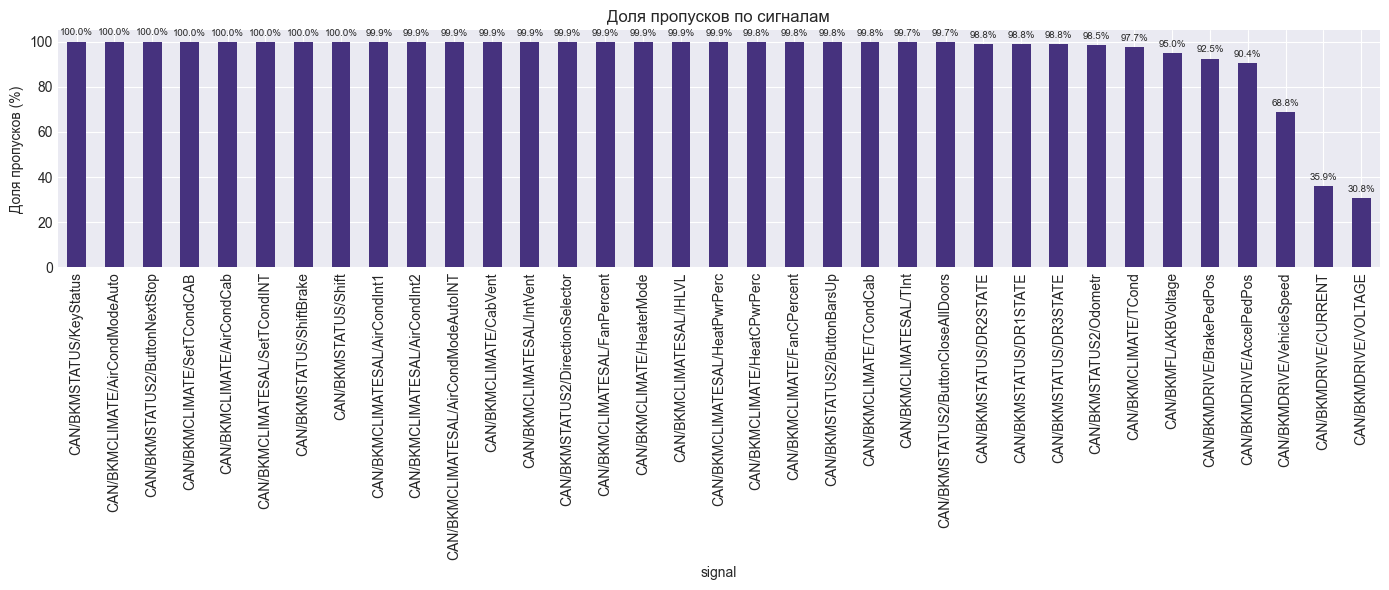

In [4]:
# Общая информация
df_wide.info()

# Доля пропусков по каждому сигналу
missing = df_wide.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df_wide)) * 100
missing_df = pd.DataFrame({'Кол-во пропусков': missing, 'Доля %': missing_pct.round(4)})
print('\n=== Пропуски по сигналам ===')
display(missing_df)

# Визуализация пропусков
plt.figure(figsize=(14, 6))
bars = missing_pct.head(35).plot(kind='bar')
plt.title('Доля пропусков по сигналам')
plt.ylabel('Доля пропусков (%)')
plt.xticks(rotation=90)
# Добавляем значения на столбцы
for bar in bars.patches:
    height = bar.get_height()
    if height > 0.5:
        bars.annotate(f'{height:.1f}%',
                      xy=(bar.get_x() + bar.get_width() / 2, height),
                      xytext=(0, 3), textcoords="offset points",
                      ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.show()

## **4. Базовые статистики**

In [5]:
# Статистики для числовых колонок
stats = df_wide.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T
stats_display = stats[['count', 'min', 'max', 'mean', 'std', '1%', '5%', '25%', '50%', '75%', '95%', '99%']]
display(stats_display)

# Дополнительно: коэффициент вариации
cv = (stats['std'] / stats['mean']).abs()
cv_df = cv.to_frame('CV (коэфф. вариации)')
cv_df['Интерпретация'] = cv_df['CV (коэфф. вариации)'].apply(
    lambda x: 'Слабая изменчивость' if x < 0.15 else ('Умеренная' if x < 0.35 else 'Сильная изменчивость')
)
print('\n=== Коэффициент вариации ===')
display(cv_df.sort_values('CV (коэфф. вариации)', ascending=False))

,count,min,max,mean,std,1%,5%,25%,50%,75%,95%,99%
signal,,,,,,,,,,,,
CAN/BKMCLIMATE/AirCondCab,583.0000,0.0000,1.0000,0.0961,0.2949,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000
CAN/BKMCLIMATE/AirCondModeAuto,110.0000,0.0000,1.0000,0.0091,0.0953,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
CAN/BKMCLIMATE/CabVent,1790.0000,0.0000,1.0000,0.5899,0.4920,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000
CAN/BKMCLIMATE/FanCPercent,2914.0000,0.0000,100.0000,41.8633,33.0191,0.0000,0.0000,0.0000,57.6000,57.6000,100.0000,100.0000
CAN/BKMCLIMATE/HeatCPwrPerc,2836.0000,0.0000,100.0000,36.2130,38.0871,0.0000,0.0000,0.0000,0.0000,60.0000,100.0000,100.0000
CAN/BKMCLIMATE/HeaterMode,2403.0000,0.0000,1.0000,0.4032,0.4907,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000
CAN/BKMCLIMATE/SetTCondCAB,423.0000,15.0000,25.0000,18.9811,3.7479,15.0000,15.0000,15.0000,18.0000,20.0000,25.0000,25.0000
CAN/BKMCLIMATE/TCond,40164.0000,4.0000,81.0000,49.6768,12.7953,11.0000,22.0000,45.0000,52.0000,57.0000,67.0000,73.0000
CAN/BKMCLIMATE/TCondCab,3487.0000,-1.0000,29.0000,16.6197,3.9763,3.0000,9.0000,15.0000,17.0000,19.0000,22.0000,28.0000



=== Коэффициент вариации ===


,CV (коэфф. вариации),Интерпретация
signal,,
CAN/BKMSTATUS/Shift,11.4804,Сильная изменчивость
CAN/BKMSTATUS/ShiftBrake,11.4804,Сильная изменчивость
CAN/BKMCLIMATE/AirCondModeAuto,10.4881,Сильная изменчивость
CAN/BKMSTATUS/KeyStatus,7.4833,Сильная изменчивость
CAN/BKMCLIMATE/AirCondCab,3.0703,Сильная изменчивость
CAN/BKMSTATUS2/ButtonCloseAllDoors,2.8715,Сильная изменчивость
CAN/BKMCLIMATESAL/IHLVL,2.7941,Сильная изменчивость
CAN/BKMSTATUS2/ButtonBarsUp,2.6302,Сильная изменчивость
CAN/BKMCLIMATESAL/HeatPwrPerc,2.6086,Сильная изменчивость


## **5. Анализ ключевых параметров электротранспорта**

Выберем наиболее важные сигналы:

- CAN/BKMDRIVE/VehicleSpeed — скорость
- CAN/BKMDRIVE/AccelPedPos — педаль газа
- CAN/BKMDRIVE/BrakePedPos — педаль тормоза
- CAN/BKMDRIVE/CURRENT — ток двигателя (или батареи)
- CAN/BKMDRIVE/VOLTAGE — напряжение
- CAN/BKMBAT/SOC — заряд батареи
- CAN/BKMFL/AKBVoltage — напряжение АКБ
- CAN/BKMBAT/BMSTemperature — температура BMS

In [6]:
key_signals = [
    'CAN/BKMDRIVE/VehicleSpeed',
    'CAN/BKMDRIVE/AccelPedPos',
    'CAN/BKMDRIVE/BrakePedPos',
    'CAN/BKMDRIVE/CURRENT',
    'CAN/BKMDRIVE/VOLTAGE',
    'CAN/BKMBAT/SOC',
    'CAN/BKMFL/AKBVoltage',
    'CAN/BKMBAT/BMSTemperature'
]

# Проверим, какие из них присутствуют
present = [s for s in key_signals if s in df_wide.columns]
absent = [s for s in key_signals if s not in df_wide.columns]
print(f"Присутствуют ({len(present)}): {present}")
if absent:
    print(f"Отсутствуют ({len(absent)}): {absent}")

# Таблица с краткой статистикой по присутствующим сигналам
key_stats = df_wide[present].describe().T[['count', 'mean', 'std', 'min', 'max']]
key_stats['Кол-во пропусков'] = df_wide[present].isnull().sum()
key_stats['Доля пропусков %'] = (key_stats['Кол-во пропусков'] / len(df_wide) * 100).round(2)
display(key_stats)

Присутствуют (6): ['CAN/BKMDRIVE/VehicleSpeed', 'CAN/BKMDRIVE/AccelPedPos', 'CAN/BKMDRIVE/BrakePedPos', 'CAN/BKMDRIVE/CURRENT', 'CAN/BKMDRIVE/VOLTAGE', 'CAN/BKMFL/AKBVoltage']
Отсутствуют (2): ['CAN/BKMBAT/SOC', 'CAN/BKMBAT/BMSTemperature']


,count,mean,std,min,max,Кол-во пропусков,Доля пропусков %
signal,,,,,,,
CAN/BKMDRIVE/VehicleSpeed,542712.0000,21.0193,13.3829,0.0000,61.5586,1198864,68.8400
CAN/BKMDRIVE/AccelPedPos,167755.0000,37.3535,30.7904,0.0000,100.0000,1573821,90.3700
CAN/BKMDRIVE/BrakePedPos,131149.0000,41.1408,31.1373,0.0000,100.0000,1610427,92.4700
CAN/BKMDRIVE/CURRENT,1116525.0000,37.0587,79.0670,-270.0000,495.0000,625051,35.8900
CAN/BKMDRIVE/VOLTAGE,1205353.0000,569.8026,241.2600,0.0000,65535.0000,536223,30.7900
CAN/BKMFL/AKBVoltage,86460.0000,27.6387,0.8593,0.1600,28.3600,1655116,95.0400


### Распределения (гистограммы) + табличные статистики

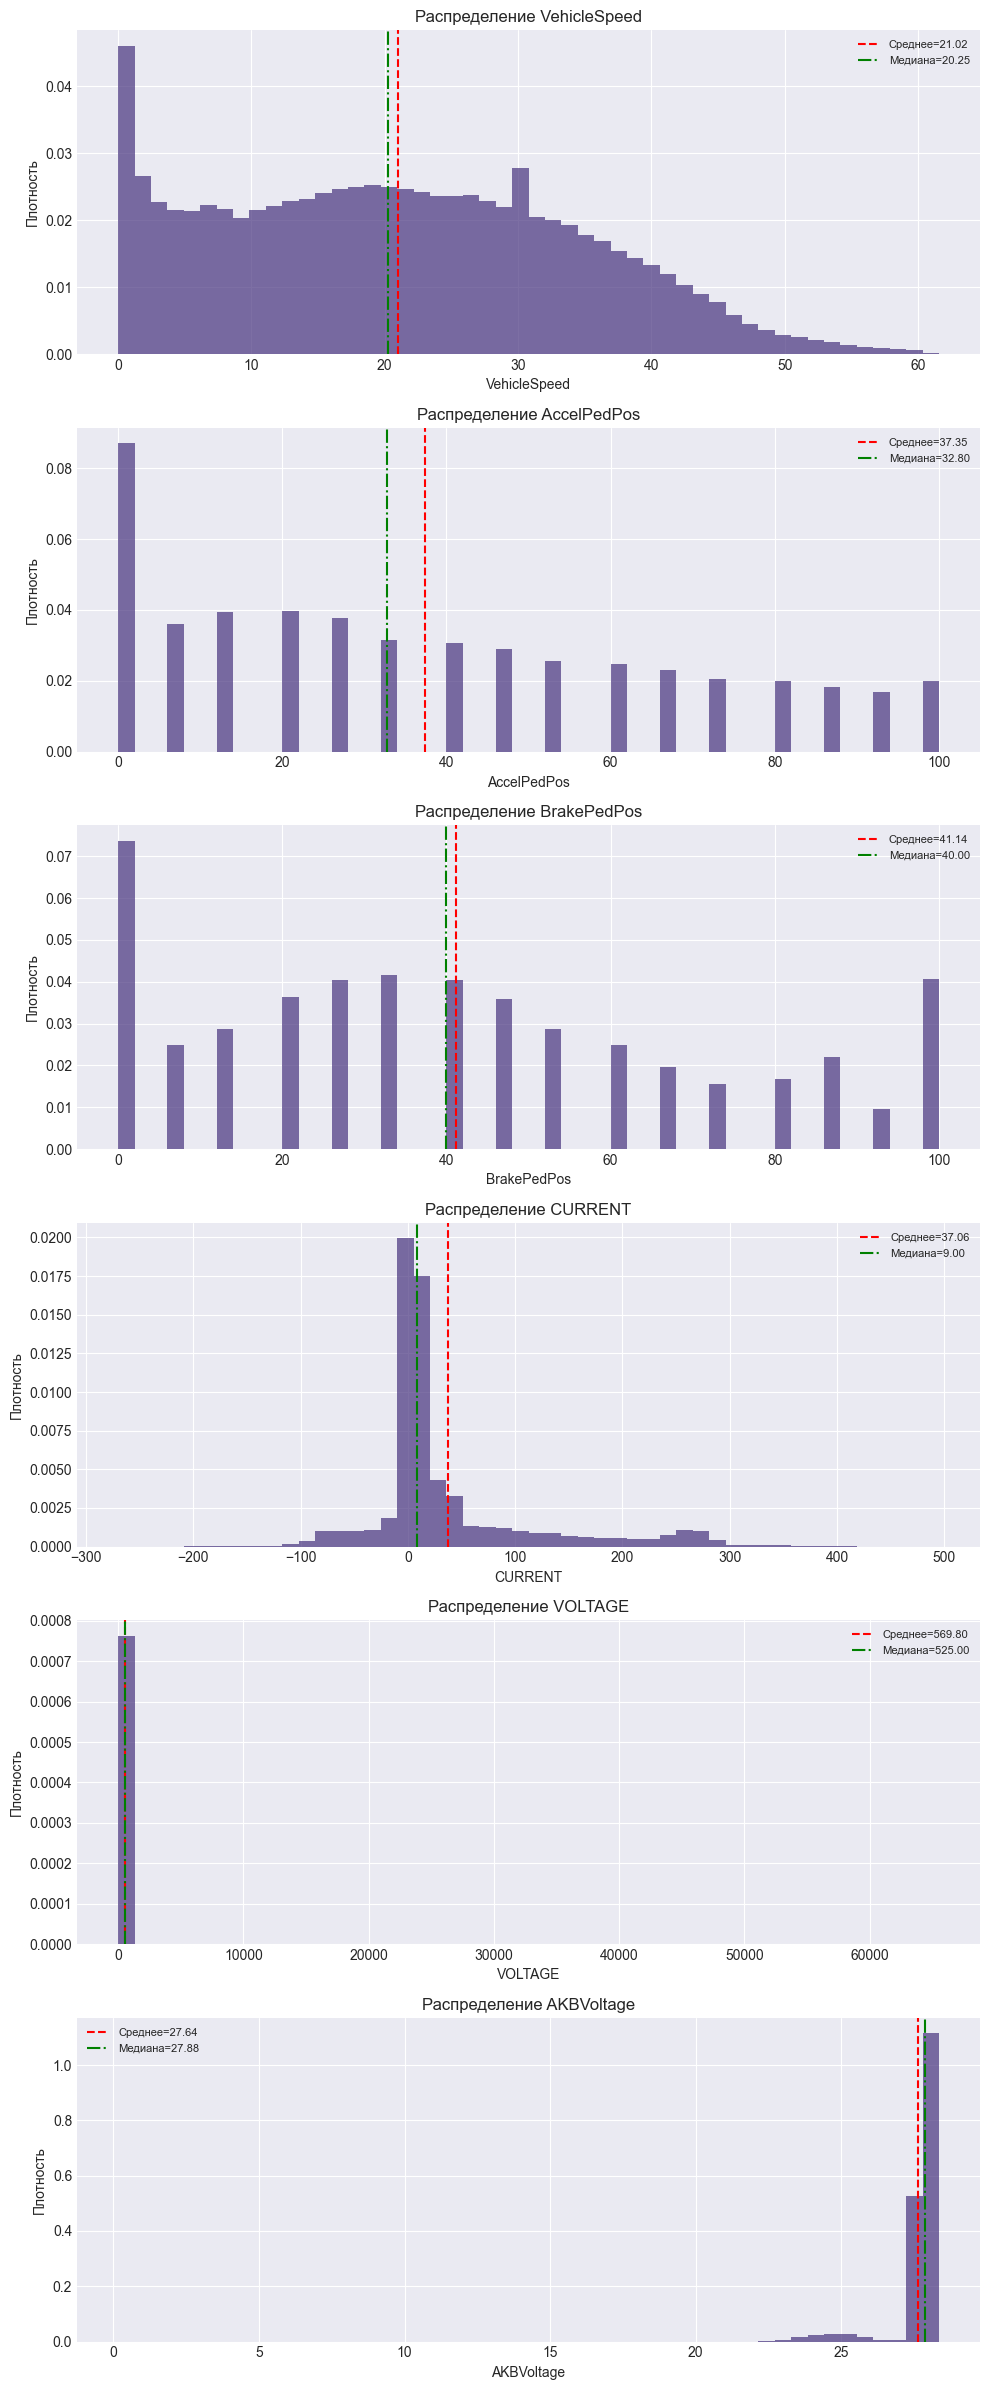


=== Статистики распределений ключевых сигналов ===


,Среднее,Медиана,СКО,Асимметрия,Эксцесс,Мин,Макс
Сигнал,,,,,,,
VehicleSpeed,21.0193,20.2500,13.3829,0.2692,-0.7476,0.0000,61.5586
AccelPedPos,37.3535,32.8000,30.7904,0.4668,-0.9636,0.0000,100.0000
BrakePedPos,41.1408,40.0000,31.1373,0.4130,-0.8970,0.0000,100.0000
CURRENT,37.0587,9.0000,79.0670,1.8318,3.2716,-270.0000,495.0000
VOLTAGE,569.8026,525.0000,241.2600,226.0758,60856.4261,0.0000,65535.0000
AKBVoltage,27.6387,27.8800,0.8593,-4.4876,45.0315,0.1600,28.3600


In [10]:
fig, axes = plt.subplots(len(present), 1, figsize=(10, 4*len(present)))
if len(present) == 1:
    axes = [axes]

# Собираем статистики для таблицы
dist_stats = []

for ax, sig in zip(axes, present):
    data = df_wide[sig].dropna()
    if len(data) == 0:
        continue
    ax.hist(data, bins=50, density=True, alpha=0.7)
    ax.set_title(f'Распределение {sig.split("/")[-1]}')
    ax.set_xlabel(sig.split('/')[-1])
    ax.set_ylabel('Плотность')
    
    # Добавляем линии медианы и среднего
    mean_val = data.mean()
    med_val = data.median()
    ax.axvline(mean_val, color='red', linestyle='--', label=f'Среднее={mean_val:.2f}')
    ax.axvline(med_val, color='green', linestyle='-.', label=f'Медиана={med_val:.2f}')
    ax.legend(loc='best', fontsize=8)
    
    # Собираем статистику
    dist_stats.append({
        'Сигнал': sig.split('/')[-1],
        'Среднее': mean_val,
        'Медиана': med_val,
        'СКО': data.std(),
        'Асимметрия': data.skew(),
        'Эксцесс': data.kurtosis(),
        'Мин': data.min(),
        'Макс': data.max()
    })

plt.tight_layout()
plt.show()

# Таблица статистик распределений
print('\n=== Статистики распределений ключевых сигналов ===')
display(pd.DataFrame(dist_stats).set_index('Сигнал'))

### Временные ряды (один день для наглядности) + табличные данные

Записей за 2026-04-20: 55166


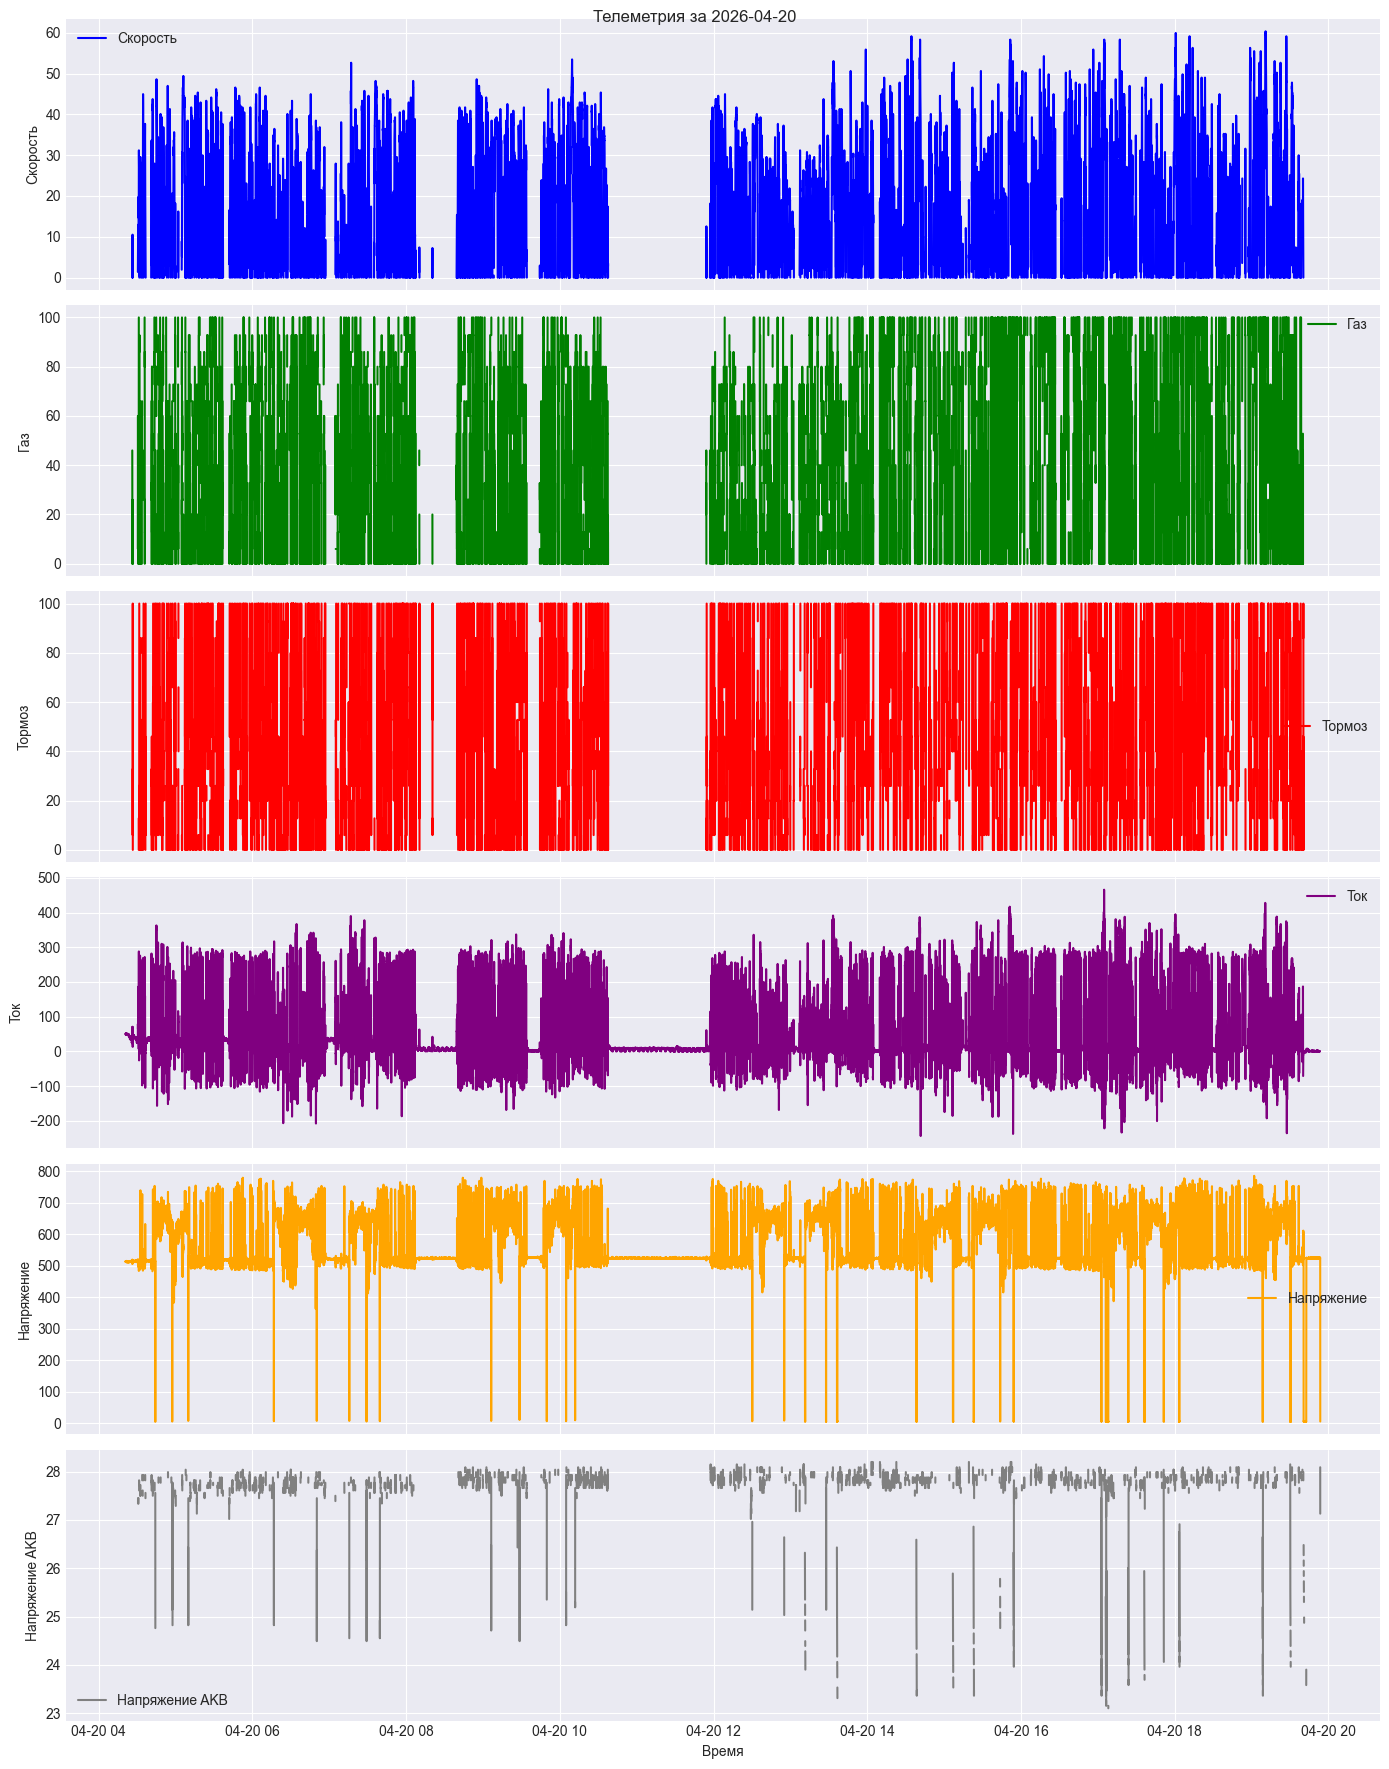


=== Почасовая агрегация за 2026-04-20 ===


signal                    CAN/BKMDRIVE/VehicleSpeed                        CAN/BKMDRIVE/AccelPedPos                         CAN/BKMDRIVE/BrakePedPos                         CAN/BKMDRIVE/CURRENT  \
                                               mean     std    min     max                     mean     std    min      max                     mean     std    min      max                 mean   
timestamp                                                                                                                                                                                           
2026-04-20 04:00:00+03:00                   20.2269 12.7126 0.0000 48.5977                  35.5019 28.5315 0.0000 100.0000                  35.2821 29.7683 0.0000 100.0000              51.9344   
2026-04-20 05:00:00+03:00                   23.8388 14.1488 0.0000 49.4062                  37.3241 30.8828 0.0000 100.0000                  42.1810 29.7296 0.0000 100.0000              57.3761   
2026-04-20 06:00:00+03:00                   18.0285 12.1695 0.0000 46.5742                  38.4125 31.4427 0.0000 100.0000                  41.3523 31.0215 0.0000 100.0000              28.9004   
2026-04-20 07:00:00+03:00                   22.0381 13.9959 0.0000 52.6484                  36.3290 29.7517 0.0000 100.0000                  39.9837 29.6081 0.0000 100.0000              54.7097   
2026-04-20 08:00:00+03:00                   23.0633 14.2155 0.0000 48.5977                  40.7728 34.3241 0.0000 100.0000                  49.5179 31.6962 0.0000 100.0000              29.3738   
2026-04-20 09:00:00+03:00                   22.9591 12.7097 0.0000 46.1680                  36.6705 30.4091 0.0000 100.0000                  38.7544 30.6124 0.0000 100.0000              27.0814   
2026-04-20 10:00:00+03:00                   23.9839 14.3829 0.0000 53.4570                  32.8103 29.0955 0.0000 100.0000                  39.2442 29.7758 0.0000 100.0000              31.6505   
2026-04-20 11:00:00+03:00                   17.6192 13.8855 0.0000 41.7148                  23.5944 20.8945 0.0000  80.0000                  29.3507 30.8375 0.0000 100.0000               7.6836   
2026-04-20 12:00:00+03:00                   22.2322 11.8683 0.0000 44.9531                  28.7079 26.9609 0.0000 100.0000                  36.0167 29.4682 0.0000 100.0000              32.3407   
2026-04-20 13:00:00+03:00                   21.3773 11.7051 0.0000 55.8867                  31.7402 29.5431 0.0000 100.0000                  41.4018 33.1658 0.0000 100.0000              38.3789   
2026-04-20 14:00:00+03:00                   23.2723 13.9864 0.0000 59.1289                  44.1880 34.4661 0.0000 100.0000                  43.3942 31.6290 0.0000 100.0000              39.0099   
2026-04-20 15:00:00+03:00                   21.1923 14.2385 0.0000 58.3164                  47.8049 34.4585 0.0000 100.0000                  47.2362 33.6913 0.0000 100.0000              40.1455   
2026-04-20 16:00:00+03:00                   23.7175 14.2326 0.0000 55.8867                  51.9553 35.5539 0.0000 100.0000                  47.7028 32.8085 0.0000 100.0000              47.1233   
2026-04-20 17:00:00+03:00                   22.7971 14.1799 0.0000 58.3164                  43.3566 32.7251 0.0000 100.0000                  39.2269 31.9886 0.0000 100.0000              40.5412   
2026-04-20 18:00:00+03:00                   24.0806 14.4548 0.0000 59.9375                  42.3085 34.7225 0.0000 100.0000                  47.0474 32.4852 0.0000 100.0000              44.6904   
2026-04-20 19:00:00+03:00                   23.9475 16.3178 0.0000 60.3438                  39.3933 34.7165 0.0000 100.0000                  43.8652 33.6359 0.0000 100.0000              36.4340   

signal                                                CAN/BKMDRIVE/VOLTAGE                            CAN/BKMFL/AKBVoltage                         
                               std       min      max                 mean      std      min      max       

In [9]:
# Выберем один день (например, 2026-04-20)
day = '2026-04-20'
mask = (df_wide.index.date == pd.to_datetime(day).date())
df_day = df_wide[mask].copy()

print(f'Записей за {day}: {len(df_day)}')

# Определяем, какие из нужных сигналов есть
drive_sigs = {
    'Скорость': 'CAN/BKMDRIVE/VehicleSpeed',
    'Газ': 'CAN/BKMDRIVE/AccelPedPos',
    'Тормоз': 'CAN/BKMDRIVE/BrakePedPos',
    'Ток': 'CAN/BKMDRIVE/CURRENT',
    'Напряжение': 'CAN/BKMDRIVE/VOLTAGE',
    'Напряжение AKB': 'CAN/BKMFL/AKBVoltage'
}

if 'CAN/BKMBAT/SOC' in df_wide.columns:
    drive_sigs['SOC'] = 'CAN/BKMBAT/SOC'

available_sigs = {k: v for k, v in drive_sigs.items() if v in df_day.columns}

fig, axes = plt.subplots(len(available_sigs), 1, figsize=(14, 3*len(available_sigs)), sharex=True)
if len(available_sigs) == 1:
    axes = [axes]

colors = {'Скорость': 'blue', 'Газ': 'green', 'Тормоз': 'red',
          'Ток': 'purple', 'Напряжение': 'orange', 'SOC': 'brown'}

for ax, (label, sig) in zip(axes, available_sigs.items()):
    ax.plot(df_day.index, df_day[sig], label=label, color=colors.get(label, 'gray'))
    ax.set_ylabel(label)
    ax.legend(loc='best')

plt.xlabel('Время')
plt.suptitle(f'Телеметрия за {day}')
plt.tight_layout()
plt.show()

# Таблица: почасовая агрегация за выбранный день
print(f'\n=== Почасовая агрегация за {day} ===')
hourly = df_day[list(available_sigs.values())].resample('1h').agg(['mean', 'std', 'min', 'max'])
display(hourly.head(24))

## **6. Корреляционный анализ**

=== Корреляционная матрица ===


signal,CAN/BKMDRIVE/VehicleSpeed,CAN/BKMDRIVE/AccelPedPos,CAN/BKMDRIVE/BrakePedPos,CAN/BKMDRIVE/CURRENT,CAN/BKMDRIVE/VOLTAGE,CAN/BKMFL/AKBVoltage
signal,,,,,,
CAN/BKMDRIVE/VehicleSpeed,1.0000,-0.3030,-0.2750,0.2640,0.0030,0.1130
CAN/BKMDRIVE/AccelPedPos,-0.3030,1.0000,-0.4680,0.5340,-0.1560,-0.2250
CAN/BKMDRIVE/BrakePedPos,-0.2750,-0.4680,1.0000,-0.2500,0.0530,0.0810
CAN/BKMDRIVE/CURRENT,0.2640,0.5340,-0.2500,1.0000,-0.0920,-0.0440
CAN/BKMDRIVE/VOLTAGE,0.0030,-0.1560,0.0530,-0.0920,1.0000,0.3380
CAN/BKMFL/AKBVoltage,0.1130,-0.2250,0.0810,-0.0440,0.3380,1.0000


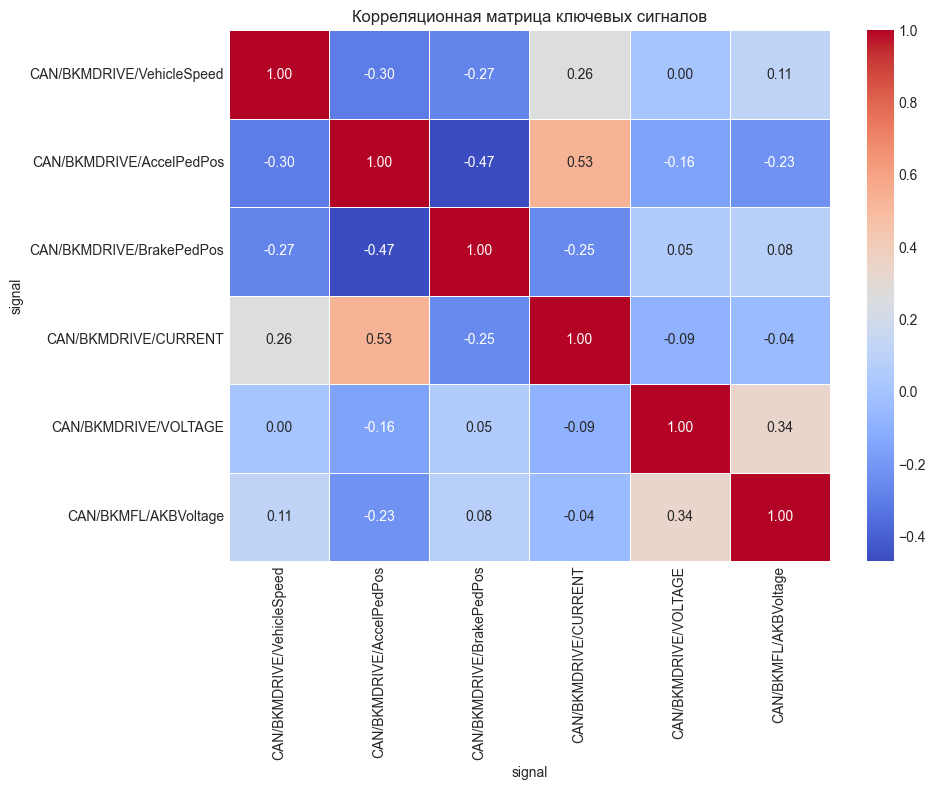

In [10]:
# Вычисляем корреляцию Пирсона для ключевых сигналов
corr_matrix = df_wide[present].corr()

# Таблица корреляций
print('=== Корреляционная матрица ===')
display(corr_matrix.round(3))

# Визуализация
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Корреляционная матрица ключевых сигналов')
plt.tight_layout()
plt.show()

# Таблица: топ-10 самых сильных корреляций (без диагонали)
#corr_pairs = (
#    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
#    .stack()
#    .reset_index()
#)
#corr_pairs.columns = ['Сигнал 1', 'Сигнал 2', 'Корреляция']
#corr_pairs['Абс. корреляция'] = corr_pairs['Корреляция'].abs()
#corr_pairs = corr_pairs.sort_values('Абс. корреляция', ascending=False)
#
#print('\n=== Топ-10 пар по силе корреляции ===')
#display(corr_pairs.head(10))

## **7. Выявление аномалий (метод IQR)**

In [11]:
def detect_outliers_iqr(data, column, multiplier=1.5):
    """Обнаружение выбросов методом IQR."""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - multiplier * IQR
    upper = Q3 + multiplier * IQR
    outliers = data[(data[column] < lower) | (data[column] > upper)]
    return outliers, lower, upper

# Таблица с результатами обнаружения выбросов
outlier_results = []

for sig in present:
    for mult in [1.5, 3.0]:
        outliers, low, high = detect_outliers_iqr(df_wide, sig, multiplier=mult)
        n_total = df_wide[sig].dropna().shape[0]
        pct = len(outliers) / n_total * 100 if n_total > 0 else 0
        outlier_results.append({
            'Сигнал': sig.split('/')[-1],
            'IQR множитель': mult,
            'Кол-во выбросов': len(outliers),
            'Доля %': round(pct, 2),
            'Нижняя граница': round(low, 2),
            'Верхняя граница': round(high, 2)
        })

outlier_df = pd.DataFrame(outlier_results)
print('=== Выбросы по методу IQR ===')
display(outlier_df)

=== Выбросы по методу IQR ===


,Сигнал,IQR множитель,Кол-во выбросов,Доля %,Нижняя граница,Верхняя граница
0,VehicleSpeed,1.5000,0,0.0000,-21.4600,62.7700
1,VehicleSpeed,3.0000,0,0.0000,-53.0500,94.3600
2,AccelPedPos,1.5000,0,0.0000,-58.0000,130.8000
3,AccelPedPos,3.0000,0,0.0000,-128.8000,201.6000
4,BrakePedPos,1.5000,0,0.0000,-58.0000,130.8000
5,BrakePedPos,3.0000,0,0.0000,-128.8000,201.6000
6,CURRENT,1.5000,224501,20.1100,-52.0000,92.0000
7,CURRENT,3.0000,123136,11.0300,-106.0000,146.0000
8,VOLTAGE,1.5000,14223,1.1800,324.5000,848.5000
9,VOLTAGE,3.0000,14210,1.1800,128.0000,1045.0000


### Визуализация выбросов для тока

Нижняя граница (-106.00), Верхняя граница (146.00)
Выбросов: 123136 (11.03%)

=== Статистика выбросов тока ===


,Значения выбросов тока
count,123136.0000
mean,222.8262
std,79.6112
min,-270.0000
25%,184.0000
50%,239.0000
75%,267.0000
max,495.0000


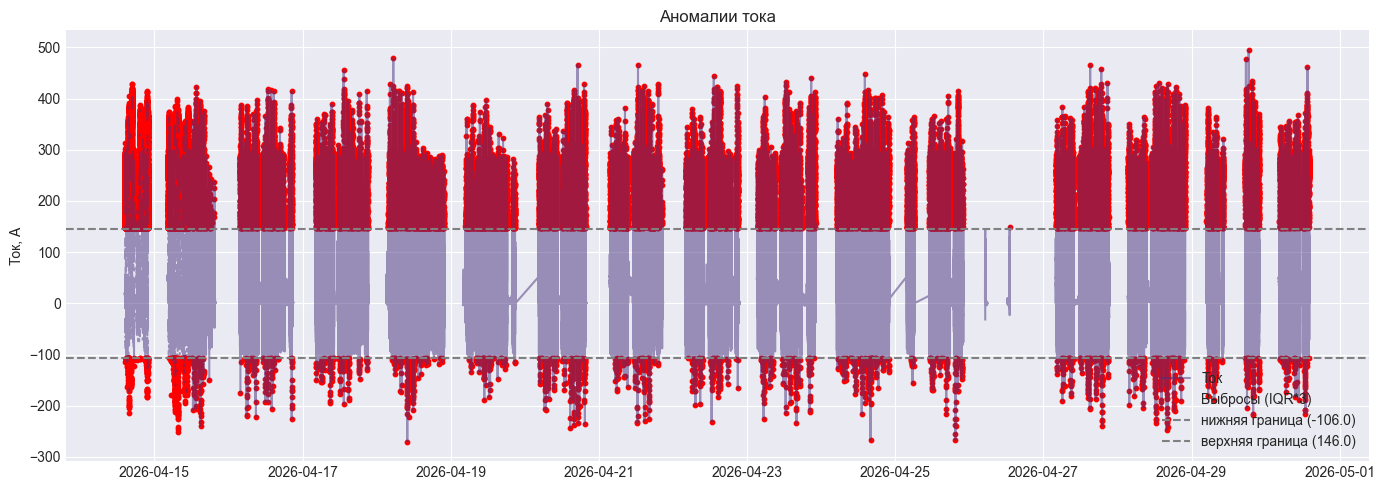

In [12]:
sig = 'CAN/BKMDRIVE/CURRENT'
if sig in df_wide.columns:
    outliers, low, high = detect_outliers_iqr(df_wide, sig, multiplier=3)
    print(f'Нижняя граница ({low:.2f}), Верхняя граница ({high:.2f})')
    print(f'Выбросов: {len(outliers)} ({len(outliers)/len(df_wide[sig].dropna())*100:.2f}%)')
    
    # Таблица: статистика выбросов тока
    print('\n=== Статистика выбросов тока ===')
    display(outliers[sig].describe().to_frame('Значения выбросов тока'))
    
    plt.figure(figsize=(14, 5))
    plt.plot(df_wide.index, df_wide[sig], alpha=0.5, label='Ток')
    plt.scatter(outliers.index, outliers[sig], color='red', s=10, label='Выбросы (IQR*3)')
    plt.axhline(y=low, color='gray', linestyle='--', label=f'нижняя граница ({low:.1f})')
    plt.axhline(y=high, color='gray', linestyle='--', label=f'верхняя граница ({high:.1f})')
    plt.title('Аномалии тока')
    plt.ylabel('Ток, А')
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()

### Визуализация выбросов для напряжения

Нижняя граница (128.00), Верхняя граница (1045.00)
Выбросов: 14210 (1.18%)

=== Статистика выбросов напряжения ===


,Значения выбросов напряжения
count,14210.0000
mean,70.1319
std,2054.1719
min,0.0000
25%,5.0000
50%,6.0000
75%,7.0000
max,65535.0000


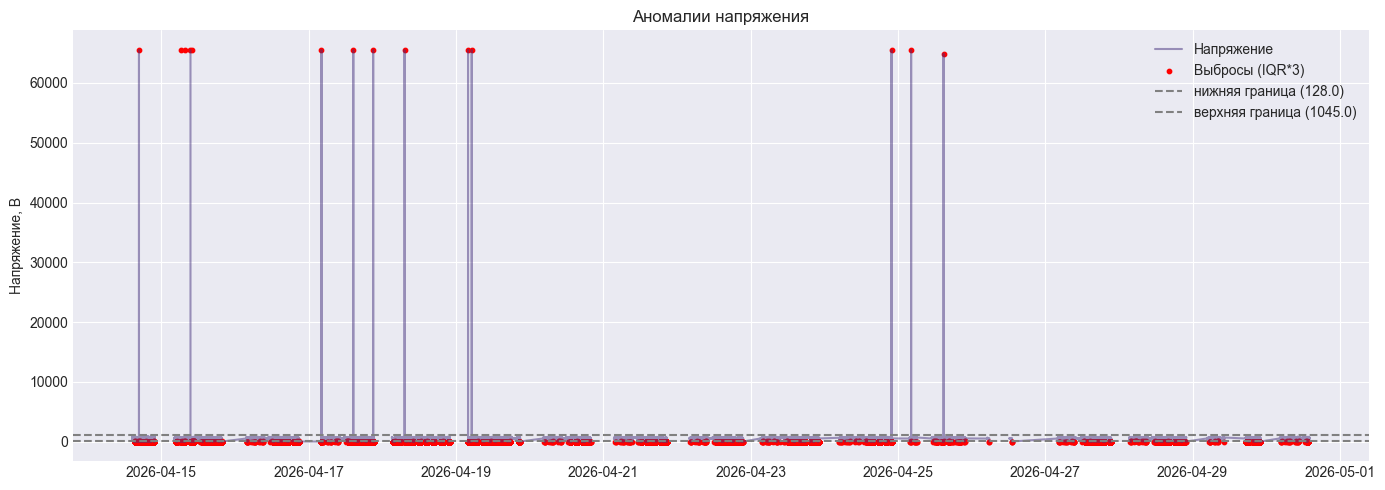

In [13]:
sig = 'CAN/BKMDRIVE/VOLTAGE'
if sig in df_wide.columns:
    outliers, low, high = detect_outliers_iqr(df_wide, sig, multiplier=3)
    print(f'Нижняя граница ({low:.2f}), Верхняя граница ({high:.2f})')
    print(f'Выбросов: {len(outliers)} ({len(outliers)/len(df_wide[sig].dropna())*100:.2f}%)')
    
    # Таблица: статистика выбросов напряжения
    print('\n=== Статистика выбросов напряжения ===')
    display(outliers[sig].describe().to_frame('Значения выбросов напряжения'))
    
    plt.figure(figsize=(14, 5))
    plt.plot(df_wide.index, df_wide[sig], alpha=0.5, label='Напряжение')
    plt.scatter(outliers.index, outliers[sig], color='red', s=10, label='Выбросы (IQR*3)')
    plt.axhline(y=low, color='gray', linestyle='--', label=f'нижняя граница ({low:.1f})')
    plt.axhline(y=high, color='gray', linestyle='--', label=f'верхняя граница ({high:.1f})')
    plt.title('Аномалии напряжения')
    plt.ylabel('Напряжение, В')
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()

### Визуализация выбросов для напряжения АКБ

Нижняя граница (26.91), Верхняя граница (28.80)
Выбросов: 6083 (7.04%)

=== Статистика выбросов напряжения АКБ===


,Значения выбросов напряжения АКБ
count,6083.0000
mean,24.7310
std,1.0311
min,0.1600
25%,24.0600
50%,24.7600
75%,25.4100
max,26.8600


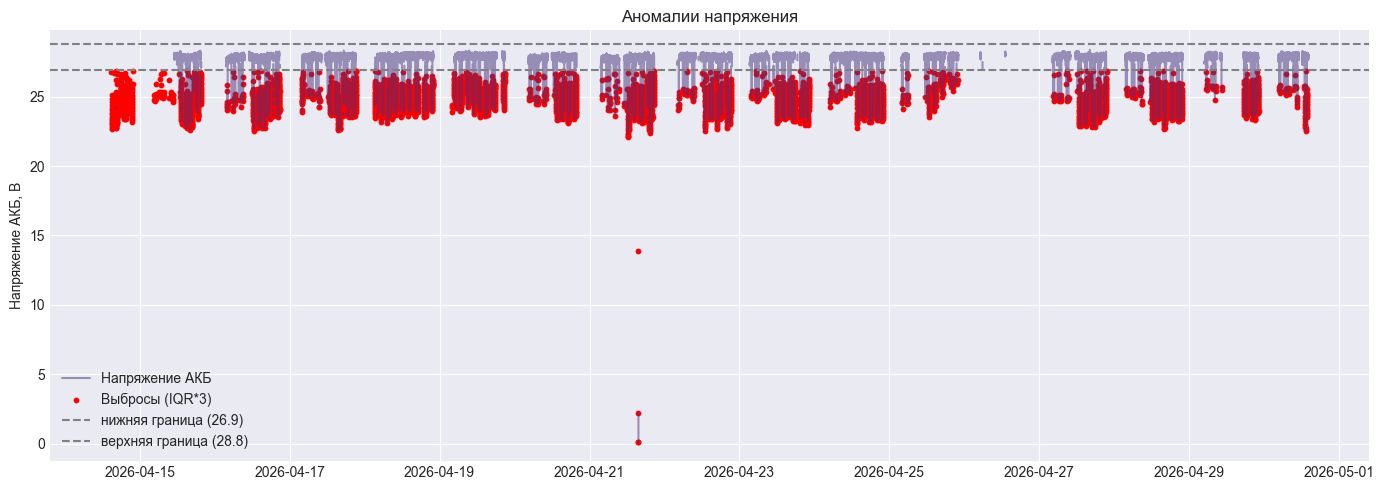

In [14]:
sig = 'CAN/BKMFL/AKBVoltage'
if sig in df_wide.columns:
    outliers, low, high = detect_outliers_iqr(df_wide, sig, multiplier=3)
    print(f'Нижняя граница ({low:.2f}), Верхняя граница ({high:.2f})')
    print(f'Выбросов: {len(outliers)} ({len(outliers)/len(df_wide[sig].dropna())*100:.2f}%)')
    
    # Таблица: статистика выбросов напряжения
    print('\n=== Статистика выбросов напряжения АКБ===')
    display(outliers[sig].describe().to_frame('Значения выбросов напряжения АКБ'))
    
    plt.figure(figsize=(14, 5))
    plt.plot(df_wide.index, df_wide[sig], alpha=0.5, label='Напряжение АКБ')
    plt.scatter(outliers.index, outliers[sig], color='red', s=10, label='Выбросы (IQR*3)')
    plt.axhline(y=low, color='gray', linestyle='--', label=f'нижняя граница ({low:.1f})')
    plt.axhline(y=high, color='gray', linestyle='--', label=f'верхняя граница ({high:.1f})')
    plt.title('Аномалии напряжения')
    plt.ylabel('Напряжение АКБ, В')
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()

## **8. Частота обновления сигналов**

In [15]:
# Оценим интервалы между записями для каждого сигнала
time_diffs = {}
for sig in df_wide.columns:
    ts = df_wide[sig].dropna().index
    if len(ts) > 1:
        diffs = (ts[1:] - ts[:-1]).total_seconds()
        time_diffs[sig] = {
            'Медиана (сек)': np.median(diffs),
            'Среднее (сек)': np.mean(diffs),
            'Мин (сек)': np.min(diffs),
            'Макс (сек)': np.max(diffs),
            '95-й перцентиль (сек)': np.percentile(diffs, 95)
        }

time_diffs_df = pd.DataFrame(time_diffs).T.sort_values('Медиана (сек)')
print('=== Частота обновления сигналов ===')
display(time_diffs_df.head(15))

print('\nСамые частые сигналы (медианный интервал, сек):')
for sig_name in time_diffs_df.head(10).index:
    med = time_diffs_df.loc[sig_name, 'Медиана (сек)']
    print(f"  {sig_name.split('/')[-1]}: {med:.3f} сек")

=== Частота обновления сигналов ===


,Медиана (сек),Среднее (сек),Мин (сек),Макс (сек),95-й перцентиль (сек)
CAN/BKMDRIVE/CURRENT,1.0000,1.2372,0.0010,53567.0000,1.0000
CAN/BKMDRIVE/VOLTAGE,1.0000,1.1460,0.0010,53565.0000,1.0000
CAN/BKMDRIVE/AccelPedPos,1.0000,8.2341,0.0010,53659.0000,24.0000
CAN/BKMDRIVE/VehicleSpeed,1.0000,2.5452,0.0010,53659.0000,1.0000
CAN/BKMDRIVE/BrakePedPos,1.0000,10.5321,0.0010,53650.0000,36.0000
CAN/BKMFL/AKBVoltage,3.0000,15.9762,0.8560,53663.0000,43.0000
CAN/BKMCLIMATE/TCond,10.0000,34.3877,0.9630,107681.0000,64.9200
CAN/BKMSTATUS2/Odometr,13.0000,52.5117,1.0000,54273.0000,110.0000
CAN/BKMSTATUS/DR2STATE,56.2010,247.2644,0.1030,409011.8720,300.0090
CAN/BKMSTATUS/DR3STATE,57.0000,246.1325,0.0780,409012.8210,300.0110



Самые частые сигналы (медианный интервал, сек):
  CURRENT: 1.000 сек
  VOLTAGE: 1.000 сек
  AccelPedPos: 1.000 сек
  VehicleSpeed: 1.000 сек
  BrakePedPos: 1.000 сек
  AKBVoltage: 3.000 сек
  TCond: 10.000 сек
  Odometr: 13.000 сек
  DR2STATE: 56.201 сек
  DR3STATE: 57.000 сек


---
## **10. ОЧИСТКА ДАННЫХ: удаление пропусков, выбросов, масштабирование**

Новый раздел, добавленный по результатам встречи с научным руководителем.

### 10.1. Удаление сигналов с критичным количеством пропусков

Сигналы, у которых доля пропусков превышает заданный порог (например, 95%), не несут полезной информации для модели и подлежат удалению.

In [16]:
# Порог удаления сигналов по доле пропусков
MISSING_THRESHOLD = 0.95  # 95%

df_clean = df_wide.copy()

# Считаем долю пропусков
missing_frac = df_clean.isnull().mean()
cols_to_drop = missing_frac[missing_frac > MISSING_THRESHOLD].index.tolist()

print(f'Сигналов до фильтрации: {len(df_clean.columns)}')
print(f'Сигналов с долей пропусков > {MISSING_THRESHOLD*100:.0f}%: {len(cols_to_drop)}')

# Таблица удаляемых сигналов
drop_info = pd.DataFrame({
    'Сигнал': cols_to_drop,
    'Доля пропусков %': [f'{missing_frac[c]*100:.2f}' for c in cols_to_drop]
})
display(drop_info)

# Удаляем
df_clean = df_clean.drop(columns=cols_to_drop)
print(f'\nСигналов после фильтрации: {len(df_clean.columns)}')
print(f'Оставшиеся сигналы: {[c.split("/")[-1] for c in df_clean.columns]}')

Сигналов до фильтрации: 35
Сигналов с долей пропусков > 95%: 30


,Сигнал,Доля пропусков %
0,CAN/BKMCLIMATE/AirCondCab,99.97
1,CAN/BKMCLIMATE/AirCondModeAuto,99.99
2,CAN/BKMCLIMATE/CabVent,99.90
3,CAN/BKMCLIMATE/FanCPercent,99.83
4,CAN/BKMCLIMATE/HeatCPwrPerc,99.84
5,CAN/BKMCLIMATE/HeaterMode,99.86
6,CAN/BKMCLIMATE/SetTCondCAB,99.98
7,CAN/BKMCLIMATE/TCond,97.69
8,CAN/BKMCLIMATE/TCondCab,99.80
9,CAN/BKMCLIMATESAL/AirCondInt1,99.94



Сигналов после фильтрации: 5
Оставшиеся сигналы: ['AccelPedPos', 'BrakePedPos', 'CURRENT', 'VOLTAGE', 'VehicleSpeed']


### 10.2. Заполнение пропусков (forward-fill + интерполяция)

Для временных рядов телеметрии логично заполнять пропуски методом forward-fill (последнее известное значение), а затем — линейной интерполяцией для оставшихся небольших разрывов.

In [17]:
print(f'Пропусков до заполнения: {df_clean.isnull().sum().sum()}')
print(f'Строк с хотя бы одним пропуском: {df_clean.isnull().any(axis=1).sum()}')

# 1. Forward-fill: распространяем последнее известное значение вперёд
df_clean = df_clean.ffill()

# 2. Backward-fill: заполняем первые строки, где ffill не сработал
df_clean = df_clean.bfill()

# 3. Линейная интерполяция (на случай оставшихся пропусков)
df_clean = df_clean.interpolate(method='linear', limit_direction='both')

# 4. Удаляем строки, где ВСЕ значения NaN (если остались)
df_clean = df_clean.dropna(how='all')

print(f'\nПропусков после заполнения: {df_clean.isnull().sum().sum()}')
print(f'Размер очищенного датафрейма: {df_clean.shape}')

# Таблица: остаточные пропуски по каждому сигналу
remaining_missing = df_clean.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]
if len(remaining_missing) > 0:
    print('Остаточные пропуски:')
    display(remaining_missing.to_frame('Кол-во'))
else:
    print('Все пропуски заполнены.')

Пропусков до заполнения: 5544386
Строк с хотя бы одним пропуском: 1739274

Пропусков после заполнения: 0
Размер очищенного датафрейма: (1741576, 5)
Все пропуски заполнены.


### 10.3. Удаление выбросов (Winsorization / обрезка по IQR)

Вместо полного удаления строк с выбросами, применяем **винсоризацию** — заменяем экстремальные значения на граничные (capping). Это сохраняет объём данных и не нарушает временной ряд.

In [18]:
def winsorize_iqr(data, column, multiplier=3.0):
    """
    Винсоризация выбросов по методу IQR.
    Значения ниже lower обрезаются до lower, выше upper — до upper.
    Возвращает Series с обработанными значениями и статистику.
    """
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - multiplier * IQR
    upper = Q3 + multiplier * IQR
    
    col_data = data[column].copy()
    n_low = (col_data < lower).sum()
    n_high = (col_data > upper).sum()
    
    col_data = col_data.clip(lower=lower, upper=upper)
    
    return col_data, lower, upper, n_low, n_high

# Применяем винсоризацию ко всем числовым колонкам
IQR_MULTIPLIER = 3.0  # жёсткая граница (3*IQR — оставляет реальные физические режимы)

winsorize_log = []

for col in df_clean.columns:
    cleaned, low, high, n_low, n_high = winsorize_iqr(df_clean, col, multiplier=IQR_MULTIPLIER)
    df_clean[col] = cleaned
    winsorize_log.append({
        'Сигнал': col.split('/')[-1],
        'Нижняя граница': round(low, 2),
        'Верхняя граница': round(high, 2),
        'Обрезано снизу': n_low,
        'Обрезано сверху': n_high,
        'Всего обрезано': n_low + n_high,
        'Доля %': round((n_low + n_high) / len(df_clean) * 100, 3)
    })

winsorize_df = pd.DataFrame(winsorize_log)
print(f'=== Винсоризация выбросов (IQR * {IQR_MULTIPLIER}) ===')
display(winsorize_df)

# Сравнение «до» и «после» для тока
sig_current = 'CAN/BKMDRIVE/CURRENT'
if sig_current in df_wide.columns and sig_current in df_clean.columns:
    print(f'\n=== Сравнение: Ток до и после винсоризации ===')
    compare = pd.DataFrame({
        'До (оригинал)': df_wide[sig_current].dropna().describe(),
        'После (winsorize)': df_clean[sig_current].describe()
    })
    display(compare)

=== Винсоризация выбросов (IQR * 3.0) ===


,Сигнал,Нижняя граница,Верхняя граница,Обрезано снизу,Обрезано сверху,Всего обрезано,Доля %
0,AccelPedPos,-18.0000,24.0000,0,343392,343392,19.7170
1,BrakePedPos,-38.4000,51.2000,0,189385,189385,10.8740
2,CURRENT,-114.0000,152.0000,3589,180397,183986,10.5640
3,VOLTAGE,128.0000,1045.0000,14959,21,14980,0.8600
4,VehicleSpeed,-66.8200,89.0900,0,0,0,0.0000



=== Сравнение: Ток до и после винсоризации ===


,До (оригинал),После (winsorize)
count,1116525.0000,1741576.0000
mean,37.0587,28.1968
std,79.0670,56.5169
min,-270.0000,-114.0000
25%,2.0000,0.0000
50%,9.0000,8.0000
75%,38.0000,38.0000
max,495.0000,152.0000


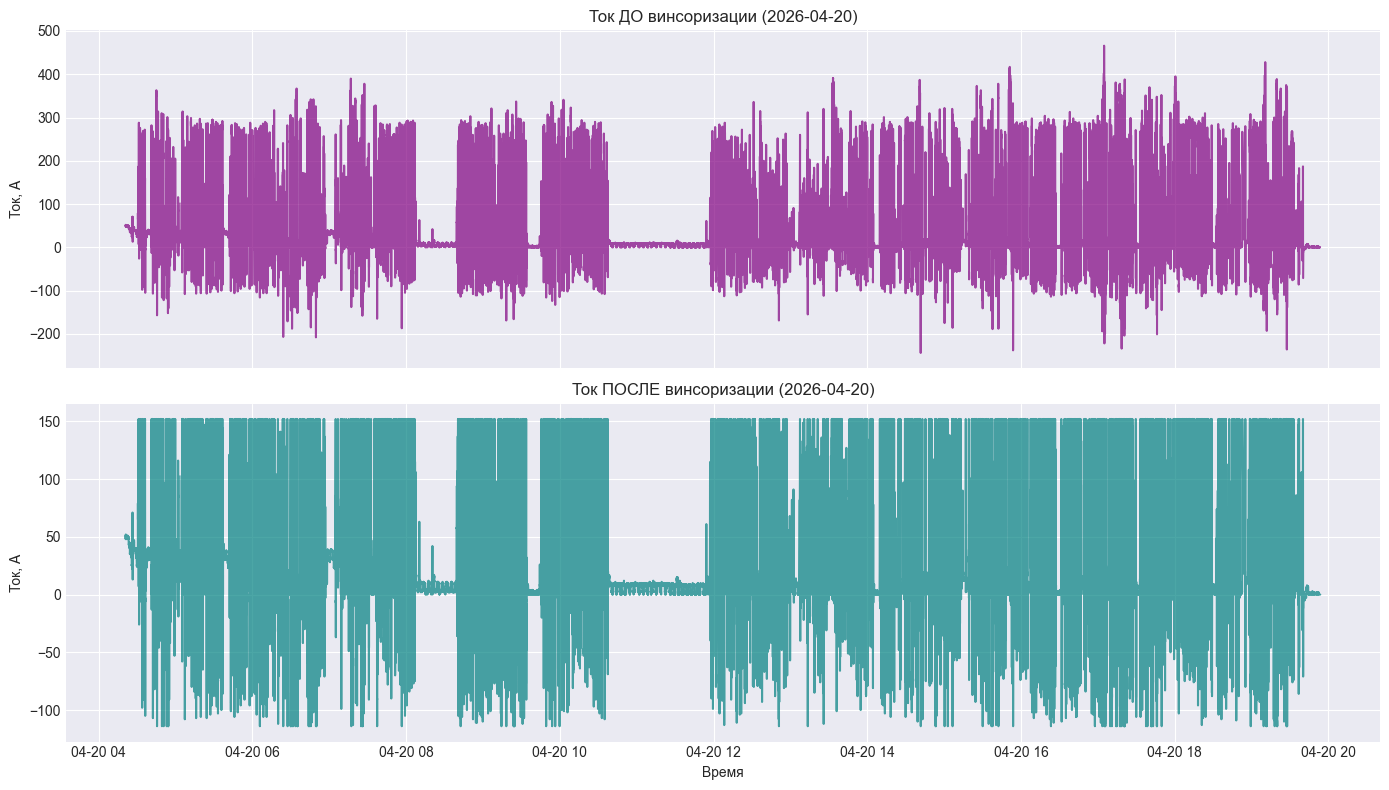

In [19]:
# Визуализация: ток до и после винсоризации (один день)
sig_current = 'CAN/BKMDRIVE/CURRENT'
if sig_current in df_wide.columns and sig_current in df_clean.columns:
    day = '2026-04-20'
    mask = (df_wide.index.date == pd.to_datetime(day).date())
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    axes[0].plot(df_wide[mask].index, df_wide[mask][sig_current], alpha=0.7, color='purple')
    axes[0].set_title(f'Ток ДО винсоризации ({day})')
    axes[0].set_ylabel('Ток, А')
    
    mask_clean = (df_clean.index.date == pd.to_datetime(day).date())
    axes[1].plot(df_clean[mask_clean].index, df_clean[mask_clean][sig_current], alpha=0.7, color='teal')
    axes[1].set_title(f'Ток ПОСЛЕ винсоризации ({day})')
    axes[1].set_ylabel('Ток, А')
    axes[1].set_xlabel('Время')
    
    plt.tight_layout()
    plt.show()

### 10.4. Масштабирование данных

Масштабирование необходимо перед подачей данных в ML-модели. Создаём два варианта:
- **MinMaxScaler** — приводит к диапазону [0, 1], сохраняя форму распределения
- **StandardScaler** — центрирует (mean=0) и нормирует (std=1)

Масштабированные данные сохраняются в отдельные датафреймы, оригинальные значения не теряются.

In [20]:
# Минимальное количество непустых значений для масштабирования
MIN_NON_NULL = 2

cols_for_scaling = [c for c in df_clean.columns if df_clean[c].notna().sum() >= MIN_NON_NULL]
print(f'Масштабированию подлежат {len(cols_for_scaling)} из {len(df_clean.columns)} сигналов')

# --- MinMaxScaler ---
scaler_minmax = MinMaxScaler()
df_scaled_minmax = pd.DataFrame(
    scaler_minmax.fit_transform(df_clean[cols_for_scaling]),
    columns=cols_for_scaling,
    index=df_clean.index
)

# --- StandardScaler ---
scaler_standard = StandardScaler()
df_scaled_standard = pd.DataFrame(
    scaler_standard.fit_transform(df_clean[cols_for_scaling]),
    columns=cols_for_scaling,
    index=df_clean.index
)

# Таблица: параметры масштабирования
scale_params = pd.DataFrame({
    'Сигнал': [c.split('/')[-1] for c in cols_for_scaling],
    'MinMax min': scaler_minmax.data_min_,
    'MinMax max': scaler_minmax.data_max_,
    'Standard mean': scaler_standard.mean_,
    'Standard std': scaler_standard.scale_
})
display(scale_params)

# Проверка
print(f'\nMinMaxScaled — диапазон: [{df_scaled_minmax.min().min():.4f}, {df_scaled_minmax.max().max():.4f}]')
print(f'StandardScaled — среднее: {df_scaled_standard.mean().mean():.6f}, СКО: {df_scaled_standard.std().mean():.4f}')

Масштабированию подлежат 5 из 5 сигналов


,Сигнал,MinMax min,MinMax max,Standard mean,Standard std
0,AccelPedPos,0.0000,24.0000,5.8356,9.7690
1,BrakePedPos,0.0000,51.2000,9.8820,18.2739
2,CURRENT,-114.0000,152.0000,28.1968,56.5169
3,VOLTAGE,128.0000,1045.0000,571.4410,85.1083
4,VehicleSpeed,0.0000,61.5586,11.7607,14.3286



MinMaxScaled — диапазон: [0.0000, 1.0000]
StandardScaled — среднее: -0.000000, СКО: 1.0000


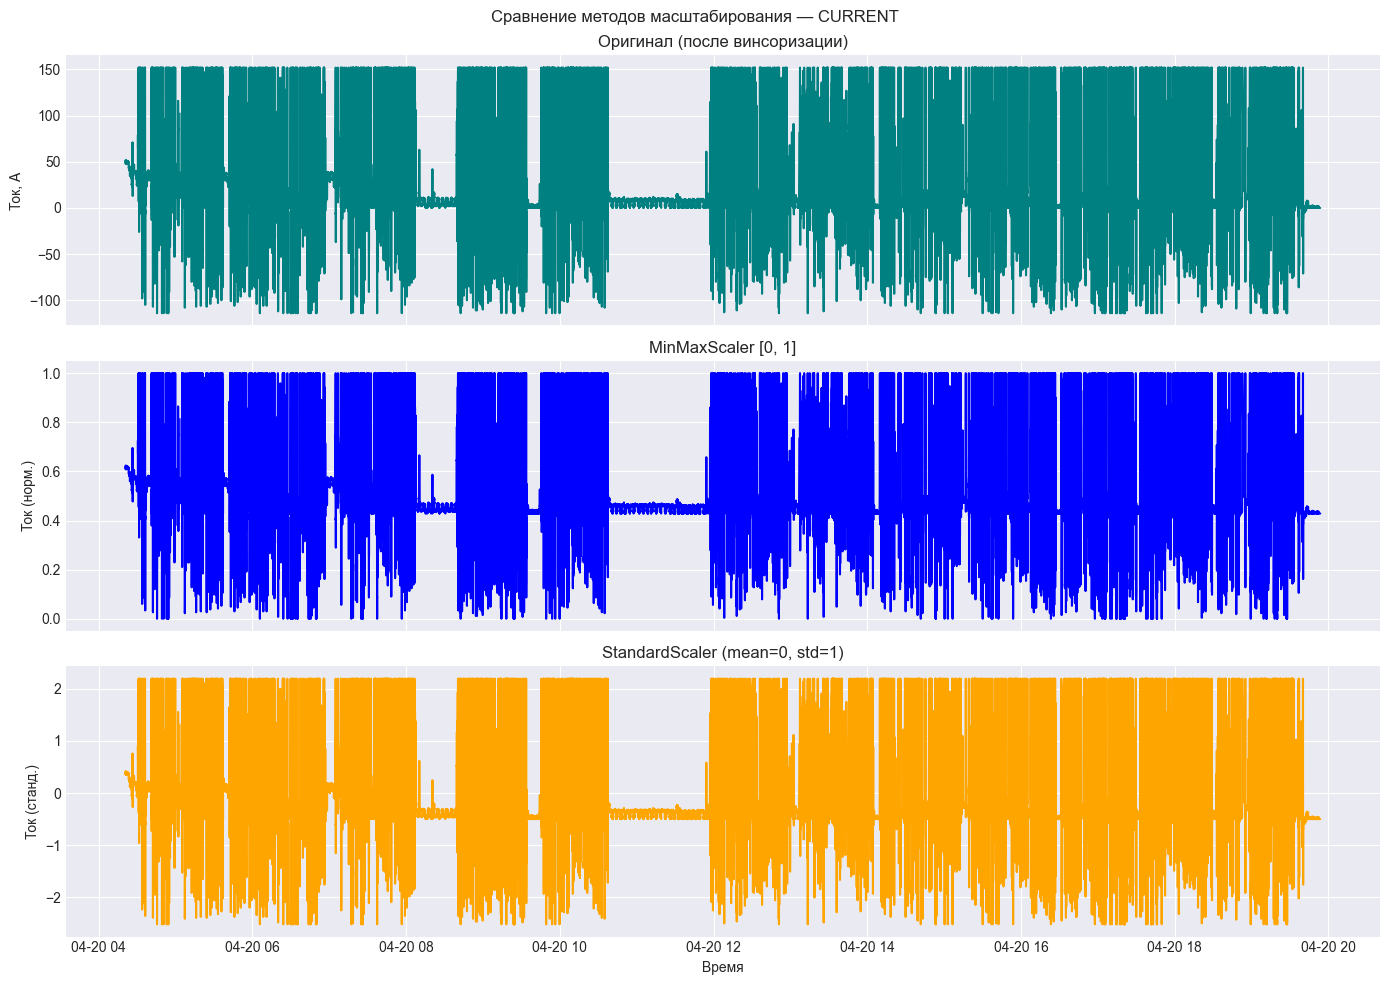

In [21]:
# Визуализация масштабирования на примере тока
sig_current = 'CAN/BKMDRIVE/CURRENT'
if sig_current in cols_for_scaling:
    day = '2026-04-20'
    mask = (df_clean.index.date == pd.to_datetime(day).date())
    
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    
    axes[0].plot(df_clean[mask].index, df_clean[mask][sig_current], color='teal')
    axes[0].set_title('Оригинал (после винсоризации)')
    axes[0].set_ylabel('Ток, А')
    
    axes[1].plot(df_scaled_minmax[mask].index, df_scaled_minmax[mask][sig_current], color='blue')
    axes[1].set_title('MinMaxScaler [0, 1]')
    axes[1].set_ylabel('Ток (норм.)')
    
    axes[2].plot(df_scaled_standard[mask].index, df_scaled_standard[mask][sig_current], color='orange')
    axes[2].set_title('StandardScaler (mean=0, std=1)')
    axes[2].set_ylabel('Ток (станд.)')
    axes[2].set_xlabel('Время')
    
    plt.suptitle(f'Сравнение методов масштабирования — {sig_current.split("/")[-1]}')
    plt.tight_layout()
    plt.show()

### 10.5. Сводная таблица: данные до и после очистки

In [22]:
summary = pd.DataFrame({
    'Показатель': [
        'Кол-во сигналов (столбцов)',
        'Кол-во записей (строк)',
        'Всего пропусков',
        'Доля пропусков %',
        'Кол-во строк с хотя бы 1 пропуском'
    ],
    'До очистки': [
        len(df_wide.columns),
        len(df_wide),
        df_wide.isnull().sum().sum(),
        f'{df_wide.isnull().mean().mean()*100:.4f}',
        df_wide.isnull().any(axis=1).sum()
    ],
    'После очистки': [
        len(df_clean.columns),
        len(df_clean),
        df_clean.isnull().sum().sum(),
        f'{df_clean.isnull().mean().mean()*100:.4f}',
        df_clean.isnull().any(axis=1).sum()
    ]
})
display(summary)

,Показатель,До очистки,После очистки
0,Кол-во сигналов (столбцов),35,5
1,Кол-во записей (строк),1741576,1741576
2,Всего пропусков,57530911,0
3,Доля пропусков %,94.3823,0.0000
4,Кол-во строк с хотя бы 1 пропуском,1741576,0


---
## **11. Фильтр Калмана для сглаживания тока**

Фильтр Калмана позволяет сгладить шум в сигнале силы тока, оценивая «истинное» значение на основе модели состояния и наблюдений. Это особенно полезно для данных телеметрии, где датчики могут давать зашумлённые показания.

In [23]:
def apply_kalman_filter(series, process_noise=1e-5, measurement_noise=1.0, initial_value=None):
    """
    Применение одномерного фильтра Калмана к временному ряду.
    
    Параметры:
    ----------
    series : pd.Series
        Временной ряд для фильтрации
    process_noise : float
        Дисперсия шума процесса (Q). Чем меньше — тем сильнее сглаживание.
    measurement_noise : float
        Дисперсия шума измерений (R). Чем больше — тем меньше доверяем наблюдениям.
    initial_value : float or None
        Начальное значение состояния. Если None — берём первое наблюдение.
    
    Возвращает:
    -----------
    pd.Series с отфильтрованными значениями
    """
    # Инициализация фильтра Калмана
    kf = KalmanFilter(dim_x=1, dim_z=1)
    
    # Начальное состояние
    if initial_value is not None:
        kf.x = np.array([[initial_value]])
    else:
        first_valid = series.dropna().iloc[0] if len(series.dropna()) > 0 else 0
        kf.x = np.array([[first_valid]])
    
    # Матрица перехода состояния (F = 1 — считаем, что значение постоянно)
    kf.F = np.array([[1.]])
    
    # Матрица наблюдения (H = 1 — наблюдаем само состояние)
    kf.H = np.array([[1.]])
    
    # Ковариация шума процесса
    kf.Q = np.array([[process_noise]])
    
    # Ковариация шума измерений
    kf.R = np.array([[measurement_noise]])
    
    # Начальная ковариация ошибки
    kf.P = np.array([[1.]])
    
    # Фильтрация
    filtered = []
    for val in series.values:
        if np.isnan(val):
            # Если NaN — только predict (predict без update)
            kf.predict()
            filtered.append(kf.x[0, 0])
        else:
            kf.predict()
            kf.update(np.array([[val]]))
            filtered.append(kf.x[0, 0])
    
    return pd.Series(filtered, index=series.index, name=series.name)


def apply_kalman_simple(series, Q=1e-5, R=1.0):
    """
    Упрощённая реализация фильтра Калмана (без filterpy).
    Работает быстрее, не требует внешних библиотек.
    
    Q — шум процесса (маленький = сильное сглаживание)
    R — шум измерений (большой = меньше доверяем наблюдениям)
    """
    x = series.dropna().iloc[0] if len(series.dropna()) > 0 else 0
    P = 1.0
    
    filtered = []
    for val in series.values:
        if np.isnan(val):
            # Predict only
            P = P + Q
            filtered.append(x)
        else:
            # Predict
            x_pred = x
            P_pred = P + Q
            # Update
            K = P_pred / (P_pred + R)  # коэффициент Калмана
            x = x_pred + K * (val - x_pred)
            P = (1 - K) * P_pred
            filtered.append(x)
    
    return pd.Series(filtered, index=series.index, name=series.name)

print('Функции фильтра Калмана определены.')

Функции фильтра Калмана определены.


In [24]:
# Применяем фильтр Калмана к току
sig_current = 'CAN/BKMDRIVE/CURRENT'

if sig_current in df_clean.columns:
    # Подбираем параметры фильтра
    # Q (process_noise): чем меньше, тем сильнее сглаживание
    # R (measurement_noise): чем больше, тем меньше доверяем каждому наблюдению
    
    # Вариант 1: слабое сглаживание (сохраняем детали)
    current_kf_light = apply_kalman_simple(df_clean[sig_current], Q=1e-3, R=1.0)
    
    # Вариант 2: среднее сглаживание
    current_kf_medium = apply_kalman_simple(df_clean[sig_current], Q=1e-5, R=5.0)
    
    # Вариант 3: сильное сглаживание
    current_kf_strong = apply_kalman_simple(df_clean[sig_current], Q=1e-7, R=20.0)
    
    # Сохраняем в df_clean средний вариант как основной
    df_clean[f'{sig_current}_kalman'] = current_kf_medium
    
    print('Фильтр Калмана применён к току. Создана колонка:', f'{sig_current}_kalman')
else:
    print(f'Сигнал {sig_current} не найден в данных')

Фильтр Калмана применён к току. Создана колонка: CAN/BKMDRIVE/CURRENT_kalman


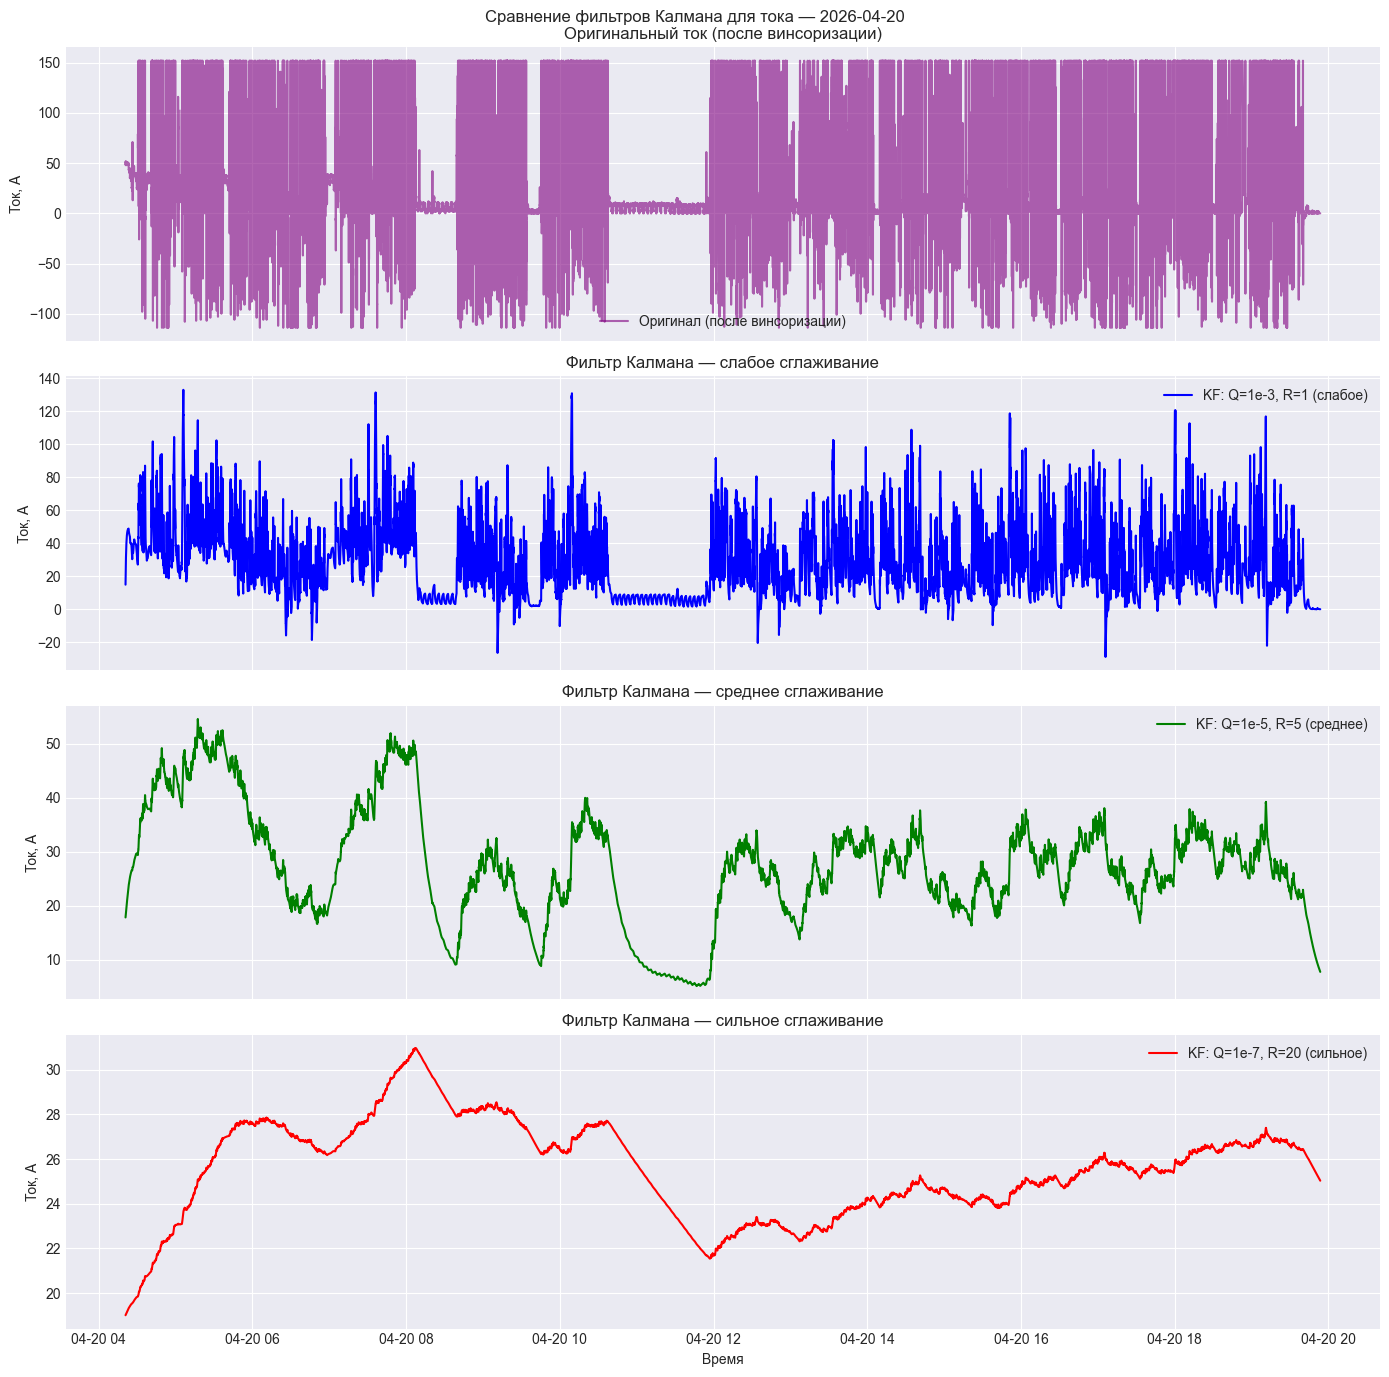

In [25]:
# Визуализация: сравнение оригинала и Kalman-сглаживания (один день)
sig_current = 'CAN/BKMDRIVE/CURRENT'
if sig_current in df_clean.columns:
    day = '2026-04-20'
    mask = (df_clean.index.date == pd.to_datetime(day).date())
    df_day_kf = df_clean[mask]
    
    fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)
    
    axes[0].plot(df_day_kf.index, df_day_kf[sig_current], alpha=0.6, color='purple', label='Оригинал (после винсоризации)')
    axes[0].set_title('Оригинальный ток (после винсоризации)')
    axes[0].set_ylabel('Ток, А')
    axes[0].legend(loc='best')
    
    axes[1].plot(df_day_kf.index, current_kf_light[mask], color='blue', label='KF: Q=1e-3, R=1 (слабое)')
    axes[1].set_title('Фильтр Калмана — слабое сглаживание')
    axes[1].set_ylabel('Ток, А')
    axes[1].legend(loc='best')
    
    axes[2].plot(df_day_kf.index, current_kf_medium[mask], color='green', label='KF: Q=1e-5, R=5 (среднее)')
    axes[2].set_title('Фильтр Калмана — среднее сглаживание')
    axes[2].set_ylabel('Ток, А')
    axes[2].legend(loc='best')
    
    axes[3].plot(df_day_kf.index, current_kf_strong[mask], color='red', label='KF: Q=1e-7, R=20 (сильное)')
    axes[3].set_title('Фильтр Калмана — сильное сглаживание')
    axes[3].set_ylabel('Ток, А')
    axes[3].legend(loc='best')
    axes[3].set_xlabel('Время')
    
    plt.suptitle(f'Сравнение фильтров Калмана для тока — {day}')
    plt.tight_layout()
    plt.show()

---
## **12. Метрики качества данных**

Оцениваем качество данных Инфоматикс по нескольким метрикам. Результаты этого раздела нужно будет потом сравнить с аналогичными метриками для «идеальных» данных CAN-шины.

In [26]:
def compute_data_quality_metrics(df_original, df_cleaned, signal_columns):
    """
    Вычисляет метрики качества данных для списка сигналов.
    
    Kalman-фильтр применяется ко ВСЕМ сигналам для оценки уровня шума.
    Для CURRENT дополнительно используется заранее вычисленная Kalman-колонка
    (если она есть в df_cleaned).
    
    Параметры:
    ----------
    df_original : pd.DataFrame — исходный датафрейм (до очистки)
    df_cleaned : pd.DataFrame — очищенный датафрейм
    signal_columns : list — список названий колонок сигналов
    
    Возвращает:
    -----------
    pd.DataFrame с метриками
    """
    results = []
    
    for sig in signal_columns:
        if sig not in df_original.columns or sig not in df_cleaned.columns:
            continue
        
        orig = df_original[sig].dropna()
        clean = df_cleaned[sig].dropna()
        
        metrics = {'Сигнал': sig.split('/')[-1]}
        
        # 1. Полнота данных
        metrics['Полнота %'] = round(len(orig) / len(df_original) * 100, 2)
        
        # 2. RMSE: оригинал vs винсоризация (на общих индексах)
        common_idx = orig.index.intersection(clean.index)
        if len(common_idx) > 0:
            rmse_wins = np.sqrt(mean_squared_error(orig.loc[common_idx], clean.loc[common_idx]))
            mae_wins = mean_absolute_error(orig.loc[common_idx], clean.loc[common_idx])
            metrics['RMSE (оригинал vs винсоризация)'] = round(rmse_wins, 4)
            metrics['MAE (оригинал vs винсоризация)'] = round(mae_wins, 4)
        
        # 3. Применяем Kalman к оригинальному сигналу для оценки шума
        #    Это даёт сопоставимую метрику для ВСЕХ сигналов
        kalman_on_orig = apply_kalman_simple(orig, Q=1e-5, R=5.0)
        rmse_kal_orig = np.sqrt(mean_squared_error(orig, kalman_on_orig))
        mae_kal_orig = mean_absolute_error(orig, kalman_on_orig)
        r2_kal_orig = r2_score(orig, kalman_on_orig)
        
        # SNR на основе оригинал vs Kalman
        noise = orig.values - kalman_on_orig.values
        signal_power = np.var(kalman_on_orig.values)
        noise_power = np.var(noise)
        snr = 10 * np.log10(signal_power / noise_power) if noise_power > 0 else float('inf')
        
        # 4. Если есть заранее вычисленная Kalman-колонка (для CURRENT) —
        #    используем её для основной метрики
        kalman_col_name = f'{sig}_kalman'
        if kalman_col_name in df_cleaned.columns:
            kalman_series = df_cleaned[kalman_col_name].dropna()
            common_idx_k = orig.index.intersection(kalman_series.index)
            if len(common_idx_k) > 0:
                rmse_kal = np.sqrt(mean_squared_error(orig.loc[common_idx_k], kalman_series.loc[common_idx_k]))
                mae_kal = mean_absolute_error(orig.loc[common_idx_k], kalman_series.loc[common_idx_k])
                r2_kal = r2_score(orig.loc[common_idx_k], kalman_series.loc[common_idx_k])
                
                noise_k = orig.loc[common_idx_k].values - kalman_series.loc[common_idx_k].values
                sp_k = np.var(kalman_series.loc[common_idx_k].values)
                np_k = np.var(noise_k)
                snr_k = 10 * np.log10(sp_k / np_k) if np_k > 0 else float('inf')
                
                # Основная метрика — Kalman из df_cleaned (для тока)
                metrics['RMSE (оригинал vs Kalman)'] = round(rmse_kal, 4)
                metrics['MAE (оригинал vs Kalman)'] = round(mae_kal, 4)
                metrics['R2 (оригинал vs Kalman)'] = round(r2_kal, 4)
                metrics['SNR (dB)'] = round(snr_k, 2)
        else:
            # Для остальных сигналов — Kalman применён «на лету» к оригиналу
            metrics['RMSE (оригинал vs Kalman)'] = round(rmse_kal_orig, 4)
            metrics['MAE (оригинал vs Kalman)'] = round(mae_kal_orig, 4)
            metrics['R2 (оригинал vs Kalman)'] = round(r2_kal_orig, 4)
            metrics['SNR (dB)'] = round(snr, 2)
        
        # 5. Выбросы
        Q1 = orig.quantile(0.25)
        Q3 = orig.quantile(0.75)
        IQR = Q3 - Q1
        n_out_15 = ((orig < Q1 - 1.5 * IQR) | (orig > Q3 + 1.5 * IQR)).sum()
        n_out_30 = ((orig < Q1 - 3 * IQR) | (orig > Q3 + 3 * IQR)).sum()
        metrics['Выбросов (IQR 1.5) %'] = round(n_out_15 / len(orig) * 100, 2)
        metrics['Выбросов (IQR 3.0) %'] = round(n_out_30 / len(orig) * 100, 2)
        
        # 6. Коэффициент вариации
        if orig.mean() != 0:
            metrics['CV (коэфф. вариации)'] = round(orig.std() / abs(orig.mean()), 4)
        else:
            metrics['CV (коэфф. вариации)'] = float('nan')
        
        results.append(metrics)
    
    return pd.DataFrame(results).set_index('Сигнал')

print('Функция compute_data_quality_metrics обновлена.')

Функция compute_data_quality_metrics обновлена.


In [27]:
# Вычисляем метрики для всех ключевых сигналов
quality_df = compute_data_quality_metrics(df_wide, df_clean, present)

print('=== Метрики качества данных Инфоматикс ===')
display(quality_df)

# Сохраняем для последующего сравнения
#quality_df.to_csv('infomatics_quality_metrics.csv', encoding='utf-8-sig')
#print('Метрики сохранены в infomatics_quality_metrics.csv')

=== Метрики качества данных Инфоматикс ===


,Полнота %,RMSE (оригинал vs винсоризация),MAE (оригинал vs винсоризация),RMSE (оригинал vs Kalman),MAE (оригинал vs Kalman),R2 (оригинал vs Kalman),SNR (dB),Выбросов (IQR 1.5) %,Выбросов (IQR 3.0) %,CV (коэфф. вариации)
Сигнал,,,,,,,,,,
VehicleSpeed,31.1600,0.0000,0.0000,12.9352,10.7966,0.0658,-11.5900,0.0000,0.0000,0.6367
AccelPedPos,9.6300,31.4892,20.0282,30.3666,25.8498,0.0273,-15.6200,0.0000,0.0000,0.8243
BrakePedPos,7.5300,18.3157,9.0599,31.0033,25.8286,0.0086,-21.2600,0.0000,0.0000,0.7568
CURRENT,64.1100,31.5934,8.7816,76.6403,46.1824,0.0604,-14.1900,20.1100,11.0300,2.1336
VOLTAGE,69.2100,219.9980,2.1897,235.6648,46.6739,0.0458,-13.3100,1.1800,1.1800,0.4234


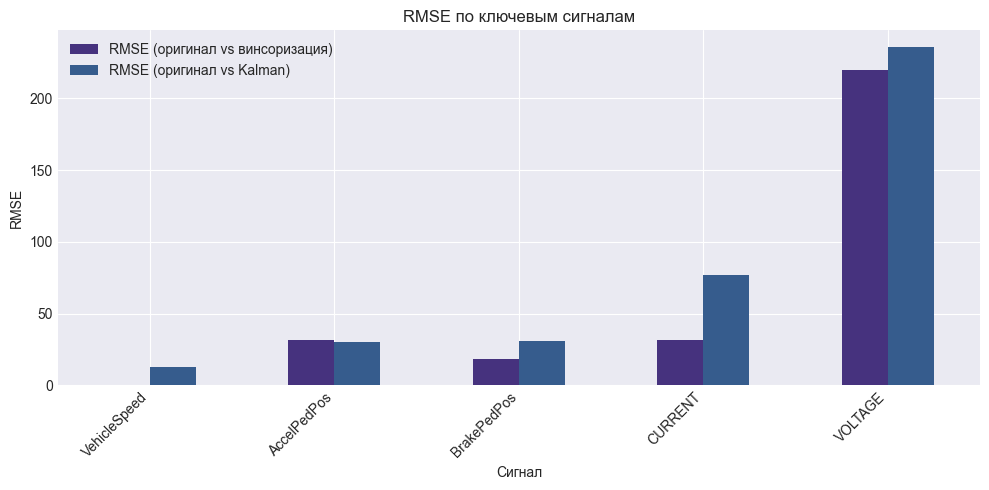

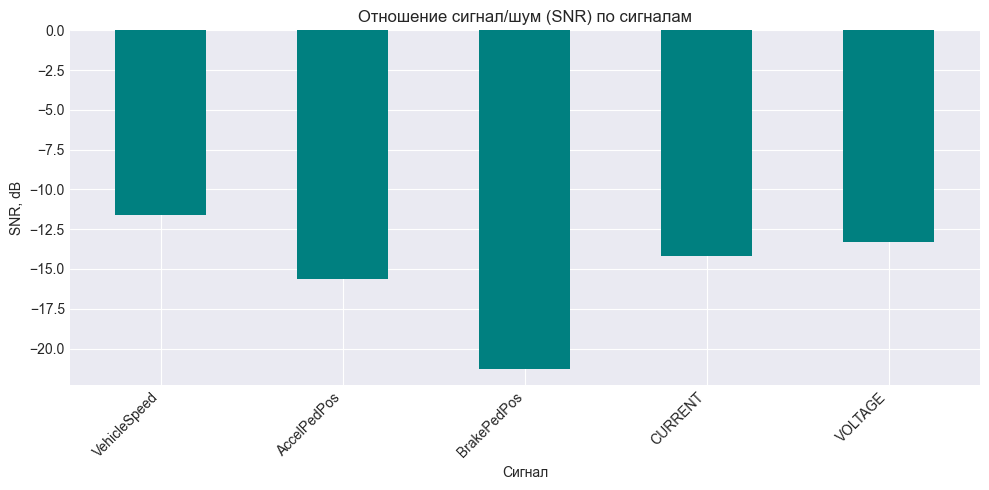

In [28]:
# Визуализация: RMSE по сигналам
rmse_cols = [c for c in quality_df.columns if 'RMSE' in c]
if rmse_cols:
    fig, ax = plt.subplots(figsize=(10, 5))
    quality_df[rmse_cols].plot(kind='bar', ax=ax)
    plt.title('RMSE по ключевым сигналам')
    plt.ylabel('RMSE')
    plt.xticks(rotation=45, ha='right')
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()

# SNR по сигналам
if 'SNR (dB)' in quality_df.columns:
    fig, ax = plt.subplots(figsize=(10, 5))
    snr_data = quality_df['SNR (dB)'].replace([np.inf, -np.inf], np.nan).dropna()
    snr_data.plot(kind='bar', ax=ax, color='teal')
    plt.title('Отношение сигнал/шум (SNR) по сигналам')
    plt.ylabel('SNR, dB')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

---
## **13. Сравнение с «идеальными» данными CAN-шины (эталонные датасеты)**

Для оценки достоверности данных Инфоматикс необходимо сравнить их метрики качества с «идеальными» данными CAN-шины от электротранспорта. Ниже представлены варианты эталонных датасетов и код для загрузки и анализа каждого.

### 13.1. Рекомендуемые эталонные датасеты

| # | Датасет | Источник | Транспорт | Сигналы | Формат | Доступ |
|---|---------|----------|-----------|---------|--------|--------|
| 1 | **JAC IEV40 Telemetry** | Kaggle | JAC IEV40 (электромобиль) | Speed, Voltage, Current, SoC, Torque, Temp | CSV | Легко (Kaggle API) |
| 2 | **EVE Pilot (Renault Zoe)** | Recherche Data Gouv | Renault Zoe (3 года) | Speed, Voltage, Current, SoC, Temp, Torque | 5 CSV | Легко (открытый) |
| 3 | **TUM UDS Dataset** | GitHub (TUM) | Cupra Born, VW ID.3 (7 BEV) | SOC, Voltage, Current, Temp, Speed | CSV | Легко (GitHub) |
| 4 | **CSS Electronics Kia EV6** | CSS Electronics | Kia EV6 (1 год) | SoC, Voltage, Current, Speed, 50+ сигналов | CSV + DBC | Легко (email) |
| 5 | **d-EVD (Dacia Spring, Nissan Leaf)** | GitHub (Vicomtech) | Dacia Spring + Nissan Leaf | SoC, Speed, Voltage, Current, Weather | CSV | Средне (форма) |
| 6 | **EVBattery/Iontech** | GitHub + Mendeley | 464 EV (3 типа) | Voltage, Current, Temp, SOC, SOH | CSV | Легко |
| 7 | **IEEE EV CAN Bus** | IEEE DataPort | 5 OEM | Raw CAN frames (Battery msgs) | Raw CAN | Средне (аккаунт) |

### Рекомендация для сравнения:
- **Лучший вариант для быстрого старта**: JAC IEV40 (Kaggle) — чистые декодированные CSV, есть ток, напряжение, скорость, SOC.
- **Лучший вариант для глубокой валидации**: EVE Pilot (Renault Zoe) — 3 года данных, полная аналогия по сигналам.
- **Лучший вариант для сырых CAN-данных**: CSS Electronics Kia EV6 — есть DBC-файл, можно декодировать CAN-фреймы.

### 13.2. Код для загрузки и анализа JAC IEV40 (Kaggle)

In [29]:
# ============================================================================
# ЭТАЛОННЫЙ ДАТАСЕТ 1: JAC IEV40 (Kaggle)
# https://www.kaggle.com/datasets/marceloreis76/electric-vehicle-telemetry-dataset
# ============================================================================

# Шаг 1: Установить kagglehub (если не установлен)
#!pip install kagglehub

# Шаг 2: Загрузить датасет
import os

KAGGLE_DATASET = "marceloreis76/electric-vehicle-telemetry-dataset"
KAGGLE_DATA_DIR = None  # Будет определено после загрузки

def load_kaggle_jac_iev40():
    """Загрузка и предобработка датасета JAC IEV40 с Kaggle."""
    try:
        import kagglehub
        path = kagglehub.dataset_download(KAGGLE_DATASET)
        print(f"Датасет загружен в: {path}")
        
        # Ищем CSV файлы
        csv_files = []
        for root, dirs, files in os.walk(path):
            for f in files:
                if f.endswith('.csv'):
                    csv_files.append(os.path.join(root, f))
        
        print(f"Найдено CSV файлов: {len(csv_files)}")
        for f in csv_files:
            print(f"  {f}")
        
        # Загружаем первый CSV (основной файл данных)
        if csv_files:
            df_kaggle = pd.read_csv(csv_files[0])
            print(f"\nРазмер данных: {df_kaggle.shape}")
            print(f"Колонки: {list(df_kaggle.columns)}")
            display(df_kaggle.head())
            return df_kaggle
        else:
            print("CSV файлы не найдены")
            return None
    except ImportError:
        print("kagglehub не установлен. Установите: pip install kagglehub")
        return None
    except Exception as e:
        print(f"Ошибка загрузки: {e}")
        return None

# Раскомментируйте для загрузки:
df_kaggle = load_kaggle_jac_iev40()

Датасет загружен в: C:\Users\Semyon\.cache\kagglehub\datasets\marceloreis76\electric-vehicle-telemetry-dataset\versions\1
Найдено CSV файлов: 1
  C:\Users\Semyon\.cache\kagglehub\datasets\marceloreis76\electric-vehicle-telemetry-dataset\versions\1\dataset.csv

Размер данных: (24277, 27)
Колонки: ['id', 'COND', 'LAT', 'LON', 'ALT', 'AX', 'AY', 'AZ', 'GX', 'GY', 'GZ', 'Y', 'M', 'D', 'H', 'MIN', 'SEC', 'CH', 'VOL', 'CUR', 'SPD', 'ODO', 'BRK', 'ACC', 'AUT', 'ECO', 'AIR']


,id,COND,LAT,LON,ALT,AX,AY,AZ,GX,GY,GZ,Y,M,D,H,MIN,SEC,CH,VOL,CUR,SPD,ODO,BRK,ACC,AUT,ECO,AIR
0,4033900000,4,-21.7830,46.6000,0.0000,196,1138,1575,24,34,7,0,0,0,0,0,0,59.0000,22,61,31,25975.4000,0,30,139,0,2
1,4114000000,4,21.0000,0.0000,0.0000,-106,813,2156,-10,12,50,0,0,0,0,0,0,52.5000,23,3,90,25998.0000,0,8,135,0,0
2,6009100000,6,21.0667,0.0000,0.0000,-82,951,1823,50,6,19,0,0,0,0,0,0,99.0000,6,2,34,26125.2000,0,0,272,0,0
3,7014600000,7,21.7995,0.0000,0.0000,130,1053,1815,-2,-8,2,0,0,0,0,0,0,84.5000,378,3,0,26200.0000,16,0,199,0,2
4,7133000000,7,-21.9251,0.0000,0.0000,432,1242,1640,-30,-62,-48,0,0,0,0,0,0,75.5000,370,20,54,26227.2000,0,16,170,0,2


### 13.3. Код для загрузки и анализа EVE Pilot — Renault Zoe (3 года)

In [30]:
# ============================================================================
# ЭТАЛОННЫЙ ДАТАСЕТ 2: EVE Pilot — Renault Zoe (3 года)
# https://recherche.data.gouv.fr/en/dataset/electric-vehicle-enquiry-eve-pilot
# ============================================================================

def load_eve_pilot(data_dir='eve_pilot_data/'):
    """
    Загрузка и предобработка датасета EVE Pilot.
    
    Перед запуском скачайте данные с:
    https://recherche.data.gouv.fr/en/dataset/electric-vehicle-enquiry-eve-pilot
    и распакуйте в папку data_dir.
    
    Файлы: automotive.csv, battery.csv, charging.csv, location.csv, summary.csv
    """
    files_map = {
        'automotive': 'automotive.csv',
        'battery': 'battery.csv',
        'charging': 'charging.csv',
        'location': 'location.csv',
        'summary': 'summary.csv'
    }
    
    datasets = {}
    for key, fname in files_map.items():
        fpath = os.path.join(data_dir, fname)
        if os.path.exists(fpath):
            datasets[key] = pd.read_csv(fpath)
            print(f"{key}: {datasets[key].shape} — колонки: {list(datasets[key].columns)}")
        else:
            print(f"Файл не найден: {fpath}")
    
    return datasets

# Раскомментируйте после скачивания данных:
# eve_datasets = load_eve_pilot('eve_pilot_data/')
# if 'battery' in eve_datasets:
#     display(eve_datasets['battery'].head())

### 13.4. Код для загрузки и анализа TUM UDS Dataset (Cupra Born / VW ID.3)

In [31]:
# ============================================================================
# ЭТАЛОННЫЙ ДАТАСЕТ 3: TUM FTM — Electric Vehicle UDS Dataset
# https://github.com/tumftm/electric-vehicle-uds-dataset
# ============================================================================

def load_tum_uds(data_dir='electric-vehicle-uds-dataset/'):
    """
    Загрузка датасета TUM UDS.
    
    Перед запуском клонируйте репозиторий:
    git clone https://github.com/tumftm/electric-vehicle-uds-dataset.git
    """
    if not os.path.exists(data_dir):
        print(f"Директория {data_dir} не найдена.")
        print("Клонируйте репозиторий:")
        print("  git clone https://github.com/tumftm/electric-vehicle-uds-dataset.git")
        return None
    
    # Ищем CSV файлы
    csv_files = []
    for root, dirs, files in os.walk(data_dir):
        for f in files:
            if f.endswith('.csv'):
                csv_files.append(os.path.join(root, f))
    
    print(f"Найдено CSV файлов: {len(csv_files)}")
    for f in csv_files[:10]:
        print(f"  {f}")
    
    # Загружаем данные
    dfs = {}
    for fpath in csv_files:
        fname = os.path.basename(fpath)
        try:
            df = pd.read_csv(fpath)
            dfs[fname] = df
            print(f"\n{fname}: {df.shape}")
            print(f"  Колонки: {list(df.columns)}")
        except Exception as e:
            print(f"Ошибка чтения {fname}: {e}")
    
    return dfs

# Раскомментируйте после клонирования:
# tum_datasets = load_tum_uds('electric-vehicle-uds-dataset/')

### 13.5. Универсальные функции для вычисления и сравнения метрик эталонного датасета

In [32]:
def compute_reference_metrics(df, signal_columns, time_column=None, dataset_name="Reference"):
    """
    Вычисляет метрики качества данных для эталонного датасета.
    
    Параметры:
    ----------
    df : pd.DataFrame
        Датафрейм с эталонными данными
    signal_columns : dict
        Маппинг: {название_сигнала_Инфоматикс: название_колонки_в_датасете}
        Пример: {'CAN/BKMDRIVE/CURRENT': 'battery_current', ...}
    time_column : str or None
        Название колонки с временной меткой (для сортировки и Kalman)
    dataset_name : str
        Название датасета для отчёта
    
    Возвращает:
    -----------
    pd.DataFrame с метриками
    """
    results = []
    
    for info_sig, ref_col in signal_columns.items():
        if ref_col not in df.columns:
            print(f"  Колонка '{ref_col}' не найдена. Пропускаем {info_sig}")
            continue
        
        series = df[ref_col].dropna()
        if len(series) < 10:
            print(f"  Слишком мало данных для {ref_col}: {len(series)}")
            continue
        
        metrics = {'Сигнал': info_sig.split('/')[-1], 'Датасет': dataset_name}
        
        # Полнота
        metrics['Полнота %'] = round(len(series) / len(df) * 100, 2)
        
        # Статистики
        metrics['Среднее'] = round(series.mean(), 4)
        metrics['СКО'] = round(series.std(), 4)
        metrics['Мин'] = round(series.min(), 4)
        metrics['Макс'] = round(series.max(), 4)
        metrics['Медиана'] = round(series.median(), 4)
        
        # Выбросы (IQR 1.5 и 3.0)
        Q1 = series.quantile(0.25)
        Q3 = series.quantile(0.75)
        IQR = Q3 - Q1
        n_out_1_5 = ((series < Q1 - 1.5 * IQR) | (series > Q3 + 1.5 * IQR)).sum()
        n_out_3 = ((series < Q1 - 3 * IQR) | (series > Q3 + 3 * IQR)).sum()
        metrics['Выбросов (IQR 1.5) %'] = round(n_out_1_5 / len(series) * 100, 2)
        metrics['Выбросов (IQR 3.0) %'] = round(n_out_3 / len(series) * 100, 2)
        
        # Коэффициент вариации
        if series.mean() != 0:
            metrics['CV'] = round(series.std() / abs(series.mean()), 4)
        else:
            metrics['CV'] = float('nan')
        
        # Фильтр Калмана + RMSE
        if time_column and time_column in df.columns:
            # Сортируем по времени и применяем Kalman
            df_sorted = df.sort_values(time_column).reset_index(drop=True)
            series_sorted = df_sorted[ref_col].dropna()
            kalman_series = apply_kalman_simple(series_sorted, Q=1e-5, R=5.0)
            
            rmse_kalman = np.sqrt(mean_squared_error(series_sorted, kalman_series))
            mae_kalman = mean_absolute_error(series_sorted, kalman_series)
            r2_kalman = r2_score(series_sorted, kalman_series)
            
            # SNR
            noise = series_sorted.values - kalman_series.values
            signal_power = np.var(kalman_series.values)
            noise_power = np.var(noise)
            snr = 10 * np.log10(signal_power / noise_power) if noise_power > 0 else float('inf')
            
            metrics['RMSE (оригинал vs Kalman)'] = round(rmse_kalman, 4)
            metrics['MAE (оригинал vs Kalman)'] = round(mae_kalman, 4)
            metrics['R2 (оригинал vs Kalman)'] = round(r2_kalman, 4)
            metrics['SNR (dB)'] = round(snr, 2)
        else:
            # Без Kalman — просто на всём массиве
            kalman_series = apply_kalman_simple(series, Q=1e-5, R=5.0)
            
            rmse_kalman = np.sqrt(mean_squared_error(series, kalman_series))
            mae_kalman = mean_absolute_error(series, kalman_series)
            r2_kalman = r2_score(series, kalman_series)
            
            noise = series.values - kalman_series.values
            signal_power = np.var(kalman_series.values)
            noise_power = np.var(noise)
            snr = 10 * np.log10(signal_power / noise_power) if noise_power > 0 else float('inf')
            
            metrics['RMSE (оригинал vs Kalman)'] = round(rmse_kalman, 4)
            metrics['MAE (оригинал vs Kalman)'] = round(mae_kalman, 4)
            metrics['R2 (оригинал vs Kalman)'] = round(r2_kalman, 4)
            metrics['SNR (dB)'] = round(snr, 2)
        
        results.append(metrics)
    
    return pd.DataFrame(results).set_index('Сигнал')

print('Функция compute_reference_metrics определена.')

Функция compute_reference_metrics определена.


In [33]:
# ============================================================================
# СРАВНЕНИЕ МЕТРИК: Инфоматикс vs Эталон
# ============================================================================

def compare_metrics(infomatics_metrics, reference_metrics, dataset_name="Reference"):
    """
    Сравнение метрик качества данных Инфоматикс и эталонного датасета.
    
    Параметры:
    ----------
    infomatics_metrics : pd.DataFrame — метрики Инфоматикс (из раздела 12)
    reference_metrics : pd.DataFrame — метрики эталонного датасета
    dataset_name : str — название эталонного датасета
    
    Возвращает:
    -----------
    pd.DataFrame с результатами сравнения
    """
    # Общие сигналы
    common_signals = infomatics_metrics.index.intersection(reference_metrics.index)
    
    if len(common_signals) == 0:
        print('Нет общих сигналов для сравнения!')
        return None
    
    comparison_rows = []
    
    for sig in common_signals:
        info_row = infomatics_metrics.loc[sig]
        ref_row = reference_metrics.loc[sig]
        
        row = {'Сигнал': sig}
        
        # Сравниваем ключевые метрики
        for metric_name in ['RMSE (оригинал vs Kalman)', 'MAE (оригинал vs Kalman)',
                            'R2 (оригинал vs Kalman)', 'SNR (dB)',
                            'Выбросов (IQR 1.5) %', 'CV (коэфф. вариации)', 'Полнота %']:
            info_val = info_row.get(metric_name, np.nan)
            ref_val = ref_row.get(metric_name, np.nan)
            
            row[f'Инфоматикс: {metric_name}'] = info_val
            row[f'{dataset_name}: {metric_name}'] = ref_val
            
            # Разница (абсолютная)
            if not (np.isnan(info_val) or np.isnan(ref_val)):
                row[f'Разница: {metric_name}'] = round(info_val - ref_val, 4)
            else:
                row[f'Разница: {metric_name}'] = np.nan
        
        comparison_rows.append(row)
    
    comparison_df = pd.DataFrame(comparison_rows).set_index('Сигнал')
    return comparison_df

print('Функция compare_metrics определена.')

# Пример использования (раскомментируйте после загрузки эталонного датасета):
# comparison = compare_metrics(quality_df, ref_metrics, 'JAC IEV40')
# display(comparison)
# 
# # Визуализация сравнения RMSE
# rmse_cols_comparison = [c for c in comparison.columns if 'RMSE' in c and 'Разница' not in c]
# if rmse_cols_comparison:
#     comparison[rmse_cols_comparison].plot(kind='bar', figsize=(10, 5))
#     plt.title('Сравнение RMSE: Инфоматикс vs Эталон')
#     plt.ylabel('RMSE')
#     plt.xticks(rotation=45, ha='right')
#     plt.legend(loc='best')
#     plt.tight_layout()
#     plt.show()

Функция compare_metrics определена.


### 13.6. JAC IEV40 (Kaggle): вычисление метрик для эталонного датасета и сравнение с Инфоматикс

In [34]:
print(df_kaggle[['Y', 'M', 'D', 'H', 'MIN', 'SEC']].describe())
print(f"\nУникальные Y: {df_kaggle['Y'].unique()}")

               Y          M          D          H        MIN        SEC
count 24277.0000 24277.0000 24277.0000 24277.0000 24277.0000 24277.0000
mean     22.9327     9.9766    24.2919    15.2511    27.8684    29.3593
std       1.2420     0.5962     1.6459     6.0250    17.5097    17.3912
min       0.0000     0.0000     0.0000     0.0000     0.0000     0.0000
25%      23.0000    10.0000    24.0000    13.0000    13.0000    14.0000
50%      23.0000    10.0000    24.0000    17.0000    27.0000    29.0000
75%      23.0000    10.0000    26.0000    18.0000    42.0000    44.0000
max      23.0000    49.0000    55.0000    83.0000    95.0000    59.0000

Уникальные Y: [ 0 23]


In [35]:
# ============================================================================
# МАППИНГ: Инфоматикс -> JAC IEV40 (Kaggle)
# ============================================================================

SIGNAL_MAPPING_JAC = {
    'CAN/BKMDRIVE/VehicleSpeed': 'SPD',
    'CAN/BKMDRIVE/CURRENT': 'CUR',
    'CAN/BKMDRIVE/VOLTAGE': 'VOL',
    'CAN/BKMDRIVE/AccelPedPos': 'ACC',
    'CAN/BKMDRIVE/BrakePedPos': 'BRK',
}

# ---------------------------------------------------------------
# Очистка даты/времени и создание timestamp
# ---------------------------------------------------------------

# 1. Фильтруем записи с невалидным годом (Y=0)
df_ref = df_kaggle[df_kaggle['Y'] > 0].copy()
print(f"Записей с Y>0: {len(df_ref)} из {len(df_kaggle)} (удалено {len(df_kaggle) - len(df_ref)})")

# 2. Фильтруем записи с нереальными значениями даты/времени
df_ref = df_ref[
    (df_ref['M'].between(1, 12)) &
    (df_ref['D'].between(1, 31)) &
    (df_ref['H'].between(0, 23)) &
    (df_ref['MIN'].between(0, 59)) &
    (df_ref['SEC'].between(0, 59))
].copy()
print(f"После фильтрации даты/времени: {len(df_ref)} записей")

# 3. Собираем timestamp (Y — это смещение от 2000: 23 → 2023)
df_ref['timestamp'] = pd.to_datetime({
    'year': 2000 + df_ref['Y'],
    'month': df_ref['M'],
    'day': df_ref['D'],
    'hour': df_ref['H'],
    'minute': df_ref['MIN'],
    'second': df_ref['SEC']
})

# 4. Сортируем по времени
df_ref = df_ref.sort_values('timestamp').reset_index(drop=True)

print(f"Период данных: {df_ref['timestamp'].min()} — {df_ref['timestamp'].max()}")
print(f"Итого записей для анализа: {len(df_ref)}")

# Быстрый взгляд на ключевые сигналы
display(df_ref[['SPD', 'CUR', 'VOL', 'ACC', 'BRK']].describe())

Записей с Y>0: 24206 из 24277 (удалено 71)
После фильтрации даты/времени: 24206 записей
Период данных: 2023-10-23 01:00:00 — 2023-10-26 20:14:12
Итого записей для анализа: 24206


,SPD,CUR,VOL,ACC,BRK
count,24206.0000,24206.0000,24206.0000,24206.0000,24206.0000
mean,56.6374,28.0948,98.5963,14.4789,1.2352
std,31.8795,54.6927,148.6534,15.3993,3.9592
min,0.0000,-52.0000,0.0000,0.0000,0.0000
25%,31.0000,-3.0000,7.0000,0.0000,0.0000
50%,57.0000,8.0000,17.0000,12.0000,0.0000
75%,82.0000,47.0000,318.0000,24.0000,0.0000
max,134.0000,301.0000,381.0000,94.0000,38.0000


In [36]:
# ============================================================================
# ВЫЧИСЛЕНИЕ МЕТРИК ЭТАЛОНА
# ============================================================================

ref_metrics = compute_reference_metrics(
    df=df_ref,
    signal_columns=SIGNAL_MAPPING_JAC,
    time_column='timestamp',
    dataset_name='JAC IEV40 (Kaggle)'
)

display(ref_metrics)

# Сохраняем
#ref_metrics.to_csv('jac_iev40_quality_metrics.csv', encoding='utf-8-sig')
#print('Метрики JAC IEV40 сохранены')

,Датасет,Полнота %,Среднее,СКО,Мин,Макс,Медиана,Выбросов (IQR 1.5) %,Выбросов (IQR 3.0) %,CV,RMSE (оригинал vs Kalman),MAE (оригинал vs Kalman),R2 (оригинал vs Kalman),SNR (dB)
Сигнал,,,,,,,,,,,,,,
VehicleSpeed,JAC IEV40 (Kaggle),100.0000,56.6374,31.8795,0,134,57.0000,0.0000,0.0000,0.5629,30.8355,26.1676,0.0644,-10.3000
CURRENT,JAC IEV40 (Kaggle),100.0000,28.0948,54.6927,-52,301,8.0000,6.7100,2.0700,1.9467,53.6765,38.3826,0.0368,-13.9700
VOLTAGE,JAC IEV40 (Kaggle),100.0000,98.5963,148.6534,0,381,17.0000,0.0000,0.0000,1.5077,44.4924,15.7549,0.9104,9.9500
AccelPedPos,JAC IEV40 (Kaggle),100.0000,14.4789,15.3993,0,94,12.0000,1.0100,0.0000,1.0636,15.1291,12.3541,0.0348,-13.8600
BrakePedPos,JAC IEV40 (Kaggle),100.0000,1.2352,3.9592,0,38,0.0000,12.6900,12.6900,3.2052,3.9167,2.1012,0.0213,-16.7500


,Инфоматикс: RMSE (оригинал vs Kalman),JAC IEV40: RMSE (оригинал vs Kalman),Разница: RMSE (оригинал vs Kalman),Инфоматикс: MAE (оригинал vs Kalman),JAC IEV40: MAE (оригинал vs Kalman),Разница: MAE (оригинал vs Kalman),Инфоматикс: R2 (оригинал vs Kalman),JAC IEV40: R2 (оригинал vs Kalman),Разница: R2 (оригинал vs Kalman),Инфоматикс: SNR (dB),JAC IEV40: SNR (dB),Разница: SNR (dB),Инфоматикс: Выбросов (IQR 1.5) %,JAC IEV40: Выбросов (IQR 1.5) %,Разница: Выбросов (IQR 1.5) %,Инфоматикс: CV (коэфф. вариации),JAC IEV40: CV (коэфф. вариации),Разница: CV (коэфф. вариации),Инфоматикс: Полнота %,JAC IEV40: Полнота %,Разница: Полнота %
Сигнал,,,,,,,,,,,,,,,,,,,,,
VehicleSpeed,12.9352,30.8355,-17.9003,10.7966,26.1676,-15.3710,0.0658,0.0644,0.0014,-11.5900,-10.3000,-1.2900,0.0000,0.0000,0.0000,0.6367,NaN,NaN,31.1600,100.0000,-68.8400
AccelPedPos,30.3666,15.1291,15.2375,25.8498,12.3541,13.4957,0.0273,0.0348,-0.0075,-15.6200,-13.8600,-1.7600,0.0000,1.0100,-1.0100,0.8243,NaN,NaN,9.6300,100.0000,-90.3700
BrakePedPos,31.0033,3.9167,27.0866,25.8286,2.1012,23.7274,0.0086,0.0213,-0.0127,-21.2600,-16.7500,-4.5100,0.0000,12.6900,-12.6900,0.7568,NaN,NaN,7.5300,100.0000,-92.4700
CURRENT,76.6403,53.6765,22.9638,46.1824,38.3826,7.7998,0.0604,0.0368,0.0236,-14.1900,-13.9700,-0.2200,20.1100,6.7100,13.4000,2.1336,NaN,NaN,64.1100,100.0000,-35.8900
VOLTAGE,235.6648,44.4924,191.1724,46.6739,15.7549,30.9190,0.0458,0.9104,-0.8646,-13.3100,9.9500,-23.2600,1.1800,0.0000,1.1800,0.4234,NaN,NaN,69.2100,100.0000,-30.7900


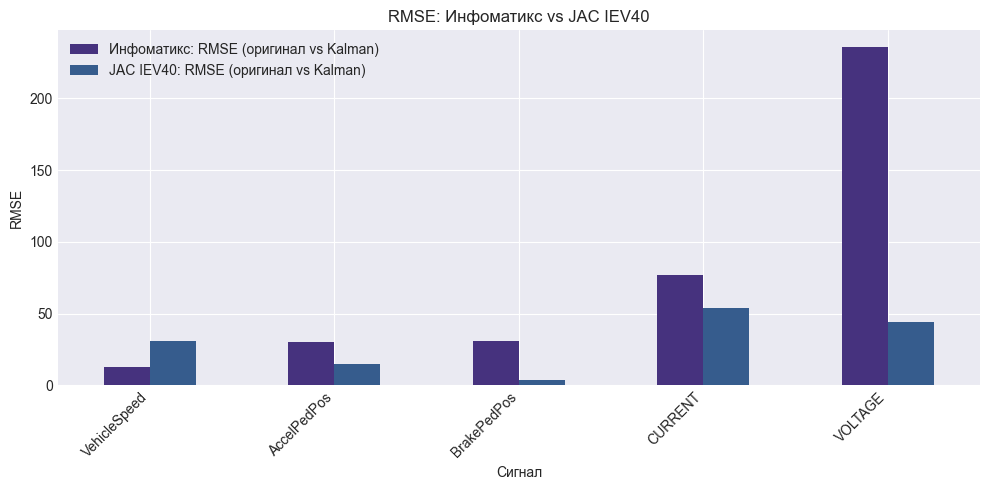

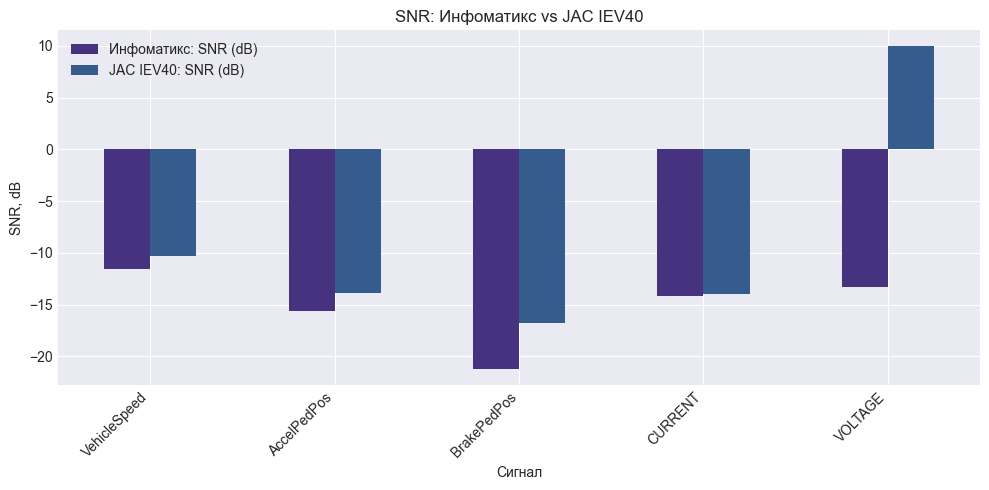

In [37]:
# ============================================================================
# СРАВНЕНИЕ: Инфоматикс vs JAC IEV40
# ============================================================================

comparison = compare_metrics(quality_df, ref_metrics, 'JAC IEV40')
display(comparison)

# Визуализация RMSE
rmse_cols = [c for c in comparison.columns if 'RMSE' in c and 'Разница' not in c]
if rmse_cols:
    comparison[rmse_cols].plot(kind='bar', figsize=(10, 5))
    plt.title('RMSE: Инфоматикс vs JAC IEV40')
    plt.ylabel('RMSE')
    plt.xticks(rotation=45, ha='right')
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()

# Визуализация SNR
snr_cols = [c for c in comparison.columns if 'SNR' in c and 'Разница' not in c]
if snr_cols:
    comparison[snr_cols].plot(kind='bar', figsize=(10, 5))
    plt.title('SNR: Инфоматикс vs JAC IEV40')
    plt.ylabel('SNR, dB')
    plt.xticks(rotation=45, ha='right')
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()

In [38]:
# Это образец маппинга
# Использовать как основу

# ============================================================================
# ПРИМЕР ИСПОЛЬЗОВАНИЯ:
# Замените df_reference на реальный датафрейм эталонного датасета
# и укажите маппинг колонок
# ============================================================================

# Маппинг: сигнал Инфоматикс -> колонка в эталонном датасете
# Заполните после загрузки реального датасета
SIGNAL_MAPPING_JAC = {
    'CAN/BKMDRIVE/VehicleSpeed': 'speed',            # Замените на реальное название
    'CAN/BKMDRIVE/CURRENT': 'battery_current',       # Замените на реальное название
    'CAN/BKMDRIVE/VOLTAGE': 'battery_voltage',       # Замените на реальное название
    'CAN/BKMDRIVE/AccelPedPos': 'accelerator_pedal', # Замените на реальное название
}

SIGNAL_MAPPING_EVE = {
    'CAN/BKMDRIVE/VehicleSpeed': 'speed',
    'CAN/BKMDRIVE/CURRENT': 'battery_current',
    'CAN/BKMDRIVE/VOLTAGE': 'battery_voltage',
}

# Пример вызова (раскомментируйте после загрузки данных):
ref_metrics = compute_reference_metrics(
    df=df_kaggle,
    signal_columns=SIGNAL_MAPPING_JAC,
    time_column='timestamp',  # Замените на реальное
    dataset_name='JAC IEV40 (Kaggle)'
)
display(ref_metrics)

print('Шаблон для сравнения готов. Заполните маппинг и загрузите датасет.')

  Колонка 'speed' не найдена. Пропускаем CAN/BKMDRIVE/VehicleSpeed
  Колонка 'battery_current' не найдена. Пропускаем CAN/BKMDRIVE/CURRENT
  Колонка 'battery_voltage' не найдена. Пропускаем CAN/BKMDRIVE/VOLTAGE
  Колонка 'accelerator_pedal' не найдена. Пропускаем CAN/BKMDRIVE/AccelPedPos


KeyError: "None of ['Сигнал'] are in the columns"

---
## **14. Сохранение обработанных данных**

In [ ]:
# Сохраняем очищенные данные в Parquet для дальнейшей работы
#df_clean.to_parquet('telemetry_clean.parquet')
#print(f"Очищенные данные сохранены в telemetry_clean.parquet ({df_clean.shape})")

# Также сохраняем масштабированные варианты
#df_scaled_minmax.to_parquet('telemetry_scaled_minmax.parquet')
#print(f"MinMax-масштабированные данные сохранены в telemetry_scaled_minmax.parquet")

#df_scaled_standard.to_parquet('telemetry_scaled_standard.parquet')
#print(f"Standard-масштабированные данные сохранены в telemetry_scaled_standard.parquet")

#print('\nВсе файлы сохранены.')

In [ ]:
!pip install fastparquet

   ---------------------------------------- 0.0/695.2 kB ? eta -:--:--
   --------------- ------------------------ 262.1/695.2 kB ? eta -:--:--
   ---------------------------------------- 695.2/695.2 kB 5.7 MB/s  0:00:00
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------------------------------ --------- 1.3/1.7 MB 7.4 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 6.5 MB/s  0:00:00

   -------------------- ------------------- 1/2 [fastparquet]
   -------------------- ------------------- 1/2 [fastparquet]
   ---------------------------------------- 2/2 [fastparquet]




[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# ============================================================
# РАЗДЕЛ 14: Сохранение очищенного датасета
# ============================================================
# РАСКОММЕНТИРОВАТЬ, если df_clean ещё не сохранён

import pyarrow

SAVE_DIR = "data/cleaned"
os.makedirs(SAVE_DIR, exist_ok=True)

# --- Сохраняем в Parquet ---
df_clean.to_parquet(
    os.path.join(SAVE_DIR, "cleaned_218.parquet"),
    index=False,
    engine="fastparquet"
)

# --- Дублирующее сохранение в CSV (для совместимости) ---
df_clean.to_csv(
    os.path.join(SAVE_DIR, "cleaned_218.csv"),
    index=False
)

# --- Метаданные очистки ---
metadata = {
    "source_file": "218",
    "missing_threshold": 0.951,
    "cleaning_date": datetime.now().isoformat(),
    "n_rows": len(df_clean),
    "n_columns": len(df_clean.columns),
    "survived_features": list(df_clean.columns),
    "dropped_features": [c for c in df_raw.columns if c not in df_clean.columns],
}

with open(os.path.join(SAVE_DIR, "clean_218_metadata.json"), "w") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print(f"✅ Датасет сохранён: {len(df_clean)} строк × {len(df_clean.columns)} признаков")
print(f"   Паркет: {SAVE_DIR}/cleaned_218.parquet")
print(f"   CSV:    {SAVE_DIR}/cleaned_218.csv")
print(f"   Мета:   {SAVE_DIR}/clean_218_metadata.json")

#print("⚠️  Раскомментируйте этот блок, если df_clean ещё не сохранён")

✅ Датасет сохранён: 1741576 строк × 7 признаков
   Паркет: data/cleaned/cleaned_218.parquet
   CSV:    data/cleaned/cleaned_218.csv
   Мета:   data/cleaned/clean_218_metadata.json


---
## **Заключение по EDA**

### Что было сделано:

1. **Удаление сигналов с критичными пропусками** — сигналы с долей пропусков > 95% удалены, т.к. не несут полезной информации для модели.

2. **Заполнение пропусков** — использован метод forward-fill + backward-fill + линейная интерполяция. Для временных рядов телеметрии это корректно, т.к. значения между обновлениями датчика логично считать неизменными.

3. **Удаление выбросов (винсоризация)** — вместо удаления строк с выбросами применена обрезка значений по границам IQR*3. Это сохраняет объём данных и не нарушает временной ряд. Для тока количество обрезанных значений отображает физические режимы разгона/рекуперации.

4. **Масштабирование** — созданы два варианта (MinMaxScaler и StandardScaler). Масштабированные данные готовы для подачи в ML-модели.

5. **Фильтр Калмана** — применён к силе тока для сглаживания шума датчика. Показаны три уровня сглаживания (слабое, среднее, сильное). Средний вариант (Q=1e-5, R=5) сохраняет форму сигнала, устраняя высокочастотный шум.

6. **Метрики качества данных** — вычислены RMSE, MAE, R2, SNR, доля выбросов, коэффициент вариации и полнота. Эти метрики можно сравнить с аналогичными для эталонных датасетов.

7. **Шаблон для сравнения с эталоном** — подготовлен код для загрузки и анализа эталонных датасетов (JAC IEV40, EVE Pilot, TUM UDS) и функции сравнения метрик.

### Рекомендуемые следующие шаги:
- Загрузить один из рекомендуемых эталонных датасетов и запустить сравнение метрик.
- Если RMSE Инфоматикс и эталона сопоставимы — данные Инфоматикс можно считать достоверными.
- Если RMSE Инфоматикс значительно выше — это указывает на повышенный шум или проблемы с качеством данных, что нужно учесть в модели предиктивного обслуживания.

# Шаг после EDA: Анализ временных рядов и построение модели для предиктивного обслуживания

In [ ]:
# 1. Импорт библиотек

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Настройки графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")
%matplotlib inline